## Jan-August Retraining Diagnostic for the Selected City Models

This notebook is a diagnostic check for the city-level TCI prediction workflow. It does not choose new model types and does not retune hyperparameters. Instead, it takes the model type, selected hyperparameters, and feature list that were already chosen by the main tuned modelling workflow, then asks a narrower question:

**If the same selected model is trained only on January-August, how well does it transfer to September-October and November-December?**

This helps separate two issues that can otherwise be mixed together:

1. whether the selected model family and parameters are reasonable;
2. whether later months are genuinely harder to predict when the model has only seen early-year data.

Workflow:

1. Load the processed prediction panels for all available cities.
2. Rebuild the same engineered predictors used by the selected city models.
3. Load each city's selected model type, hyperparameters, and feature columns from the main tuned-model output.
4. Retrain that selected model from scratch using only January-August.
5. Evaluate the retrained model on September-October and November-December separately.
6. Compare period-level error, monthly error, feature importance, and feature-group ablation diagnostics.

The November-December period remains a diagnostic test period here. It is not used to change the selected model after seeing results.


In [1]:
from pathlib import Path
import json
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
    XGBOOST_IMPORT_ERROR = None
except Exception as exc:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = exc

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
TARGET_COL = "tci"
CITY_COL = "city"
SPATIAL_ID_COL = "spatial_id"
YEAR_COL = "year"
MONTH_COL = "month"

def find_project_root(start=None) -> Path:
    """Find the NO2_Mobility_Project root from the current notebook location."""
    current = (start or Path.cwd()).resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "data").exists() and (candidate / "ml_model_training_and_evaluation").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Run this notebook from within the "
        "NO2_Mobility_Project folder or one of its subfolders."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
PANEL_DIR = DATA_DIR / "PanelProcessed"

# Main tuned-model source outputs. This should match the current city-specific model run with month as a feature.
MAIN_MODEL_OUTPUT_ROOT = DATA_DIR / "ModelOutputs" / "tci_city_models_with_geo_raw_full_range_v27"
MAIN_MODEL_SCENARIO_ID = "raw_tci_full_range_train_jan_aug_validate_sep_oct_test_nov_dec_with_month"
MAIN_MODEL_SCENARIO_ROOT = MAIN_MODEL_OUTPUT_ROOT / MAIN_MODEL_SCENARIO_ID

OUTPUT_ROOT = DATA_DIR / "ModelOutputs" / "tci_city_models_retrain_jan_aug_compare_val_test_v25"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

CITY_PANEL_FILES = {
    path.name.replace("_prediction_model_panel.csv", ""): path
    for path in sorted(PANEL_DIR.glob("*_prediction_model_panel.csv"))
}

if not CITY_PANEL_FILES:
    raise FileNotFoundError(f"No prediction model panels found in {PANEL_DIR}")
if not MAIN_MODEL_SCENARIO_ROOT.exists():
    raise FileNotFoundError(
        f"Main tuned-model source output was not found: {MAIN_MODEL_SCENARIO_ROOT}. "
        "Run the main tuned-model notebook first, or update MAIN_MODEL_SCENARIO_ID."
    )

RUN_CITIES = list(CITY_PANEL_FILES)

TRAIN_MONTHS = [1, 2, 3, 4, 5, 6, 7, 8]
VALIDATION_MONTHS = [9, 10]
TEST_MONTHS = [11, 12]
EXCLUDED_MONTHS = [7, 8]

print("Python executable:", sys.executable)
print("Panel directory:", PANEL_DIR)
print("Main tuned-model source:", MAIN_MODEL_SCENARIO_ROOT)
print("Output directory:", OUTPUT_ROOT)
print("Run cities:", RUN_CITIES)
print("Train months:", TRAIN_MONTHS)
print("Validation months:", VALIDATION_MONTHS)
print("Test months:", TEST_MONTHS)
print("XGBoost available:", XGBOOST_AVAILABLE)
if not XGBOOST_AVAILABLE:
    print("XGBoost import error:", repr(XGBOOST_IMPORT_ERROR))




Python executable: /usr/local/bin/python3
Panel directory: NO2_Mobility_Project/data/PanelProcessed
Main tuned-model source: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v27/raw_tci_full_range_train_jan_aug_validate_sep_oct_test_nov_dec_with_month
Output directory: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25
Run cities: ['baghdad', 'buenos_aires', 'cairo', 'dakar', 'lima', 'mexico_city', 'mumbai', 'new_york']
Train months: [1, 2, 3, 4, 5, 6, 7, 8]
Validation months: [9, 10]
Test months: [11, 12]
XGBoost available: True


## 1. Load City Prediction Panels

Each input row is one city-grid-month observation. The target is raw monthly `tci`; it is not log-transformed and no tail trimming is applied.

The panels should contain city/grid/month identifiers, the target variable, dynamic predictors such as NO₂ and weather, static urban predictors, and geographic coordinates.


In [2]:
city_panels = {}
load_rows = []

for city, path in CITY_PANEL_FILES.items():
    panel = pd.read_csv(path)
    panel[CITY_COL] = panel[CITY_COL].astype(str)
    panel[SPATIAL_ID_COL] = panel[SPATIAL_ID_COL].astype(str)
    panel[YEAR_COL] = pd.to_numeric(panel[YEAR_COL], errors="coerce").astype("Int64")
    panel[MONTH_COL] = pd.to_numeric(panel[MONTH_COL], errors="coerce").astype("Int64")
    city_panels[city] = panel
    load_rows.append({
        "city": city,
        "path": str(path),
        "rows": len(panel),
        "spatial_ids": panel[SPATIAL_ID_COL].nunique(),
        "months": sorted(panel[MONTH_COL].dropna().astype(int).unique().tolist()),
    })

load_summary = pd.DataFrame(load_rows).sort_values("city")
load_summary_path = OUTPUT_ROOT / "loaded_panel_summary.csv"
load_summary.to_csv(load_summary_path, index=False)
print("Saved load summary:", load_summary_path)
display(load_summary)




Saved load summary: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/loaded_panel_summary.csv


,city,path,rows,spatial_ids,months
0,baghdad,NO2_Mobility_Project/...,34138,3737,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
1,buenos_aires,NO2_Mobility_Project/...,38323,3753,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
2,cairo,NO2_Mobility_Project/...,25959,2964,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
3,dakar,NO2_Mobility_Project/...,3681,380,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
4,lima,NO2_Mobility_Project/...,10732,1032,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
5,mexico_city,NO2_Mobility_Project/...,41319,4680,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
6,mumbai,NO2_Mobility_Project/...,3108,506,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
7,new_york,NO2_Mobility_Project/...,9467,795,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"


## 2. Rebuild the Engineered Feature Set

This section recreates the explanatory-variable transformations used by the selected city models. The target remains raw `tci`; transformations are applied only to predictors.

The engineered features include geographic context, log-scale variables, road shares, POI shares, and `month` as a numeric feature. The exact feature list used for each city is loaded from that city's selected model artifact, so this diagnostic follows the selected model structure exactly.


In [3]:
ROAD_LENGTH_COLS = [
    "road_length_motorway_m",
    "road_length_primary_m",
    "road_length_residential_m",
    "road_length_secondary_m",
    "road_length_tertiary_m",
    "road_length_trunk_m",
    "road_length_unclassified_m",
]

POI_COLS = [
    "poi_business_n_business",
    "poi_commercial_n_commercial",
    "poi_education_n_education",
    "poi_leisure_n_leisure",
]

SPATIAL_ENGINEERED_COLS = [
    "centroid_lon_centered",
    "centroid_lat_centered",
    "centroid_x_km_from_city_center",
    "centroid_y_km_from_city_center",
    "distance_to_city_center_km",
]

BASE_REQUIRED_COLS = [
    TARGET_COL,
    CITY_COL,
    SPATIAL_ID_COL,
    YEAR_COL,
    MONTH_COL,
    "no2",
    "era5_temp",
    "centroid_lon",
    "centroid_lat",
    "holiday_is_off_days",
    "wind_speed",
    "population",
    "building_height",
    "pt_count_points",
    "pt_count_lines",
    "pt_count_polygon",
    "pt_total",
    "road_length_motorway_m",
    "road_length_primary_m",
    "road_length_residential_m",
    "road_length_secondary_m",
    "road_length_tertiary_m",
    "road_length_trunk_m",
    "road_length_unclassified_m",
    "road_length_total_m",
    "poi_business_n_business",
    "poi_commercial_n_commercial",
    "poi_education_n_education",
    "poi_leisure_n_leisure",
    "power_plant_n_power_plant",
]


def safe_log1p(series: pd.Series) -> pd.Series:
    return np.log1p(series.clip(lower=0))


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    unique_grid_locations = (
        out[[SPATIAL_ID_COL, "centroid_lon", "centroid_lat"]]
        .drop_duplicates(subset=[SPATIAL_ID_COL])
        .dropna(subset=["centroid_lon", "centroid_lat"])
    )
    city_lon_center = unique_grid_locations["centroid_lon"].mean()
    city_lat_center = unique_grid_locations["centroid_lat"].mean()
    km_per_degree_lat = 111.32
    km_per_degree_lon = 111.32 * np.cos(np.deg2rad(city_lat_center))

    out["centroid_lon_centered"] = out["centroid_lon"] - city_lon_center
    out["centroid_lat_centered"] = out["centroid_lat"] - city_lat_center
    out["centroid_x_km_from_city_center"] = out["centroid_lon_centered"] * km_per_degree_lon
    out["centroid_y_km_from_city_center"] = out["centroid_lat_centered"] * km_per_degree_lat
    out["distance_to_city_center_km"] = np.sqrt(
        out["centroid_x_km_from_city_center"] ** 2
        + out["centroid_y_km_from_city_center"] ** 2
    )

    out["log_population"] = safe_log1p(out["population"])
    out["log_pt_total"] = safe_log1p(out["pt_total"])
    out["log_road_length_total_m"] = safe_log1p(out["road_length_total_m"])
    out["log_power_plant_n_power_plant"] = safe_log1p(out["power_plant_n_power_plant"])

    out["poi_total"] = out[POI_COLS].sum(axis=1)
    out["log_poi_total"] = safe_log1p(out["poi_total"])

    road_total = out["road_length_total_m"].replace(0, np.nan)
    for col in ROAD_LENGTH_COLS:
        out[f"{col}_share"] = (out[col] / road_total).fillna(0)

    poi_total = out["poi_total"].replace(0, np.nan)
    for col in POI_COLS:
        out[f"{col}_share"] = (out[col] / poi_total).fillna(0)

    return out


engineered_city_panels = {}
feature_audit_rows = []

for city, panel in city_panels.items():
    missing_base = [col for col in BASE_REQUIRED_COLS if col not in panel.columns]
    if missing_base:
        raise ValueError(f"{city}: missing required columns before feature engineering: {missing_base}")

    engineered = add_engineered_features(panel)
    engineered_city_panels[city] = engineered
    feature_audit_rows.append({
        "city": city,
        "rows": len(engineered),
        "spatial_ids": engineered[SPATIAL_ID_COL].nunique(),
        "has_month_feature": MONTH_COL in engineered.columns,
    })

feature_audit = pd.DataFrame(feature_audit_rows).sort_values("city")
feature_audit_path = OUTPUT_ROOT / "feature_engineering_audit.csv"
feature_audit.to_csv(feature_audit_path, index=False)
print("Saved feature audit:", feature_audit_path)
display(feature_audit)




Saved feature audit: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/feature_engineering_audit.csv


,city,rows,spatial_ids,has_month_feature
0,baghdad,34138,3737,True
1,buenos_aires,38323,3753,True
2,cairo,25959,2964,True
3,dakar,3681,380,True
4,lima,10732,1032,True
5,mexico_city,41319,4680,True
6,mumbai,3108,506,True
7,new_york,9467,795,True


## 3. Load Selected Model Types, Hyperparameters, and Feature Lists

For each city, this section reads the saved model artifact from the main tuned-model output. The artifact provides:

- the selected model family;
- the selected hyperparameters;
- the exact feature columns used by that city's model;
- the final test metrics from the main model run.

The already-trained model object is not reused. This notebook rebuilds the model from scratch and retrains it only on January-August for the diagnostic comparison.


In [4]:
selected_model_rows = []
selected_artifacts = {}
missing_artifacts = []

for city in RUN_CITIES:
    artifact_path = MAIN_MODEL_SCENARIO_ROOT / city / "model_artifact.joblib"
    metrics_path = MAIN_MODEL_SCENARIO_ROOT / city / "metrics.csv"
    if not artifact_path.exists():
        missing_artifacts.append({"city": city, "missing_artifact": str(artifact_path)})
        continue

    artifact = joblib.load(artifact_path)
    metrics = pd.read_csv(metrics_path).iloc[0].to_dict() if metrics_path.exists() else {}
    feature_cols = artifact["feature_cols"]
    selected_artifacts[city] = {
        "artifact_path": artifact_path,
        "model_name": artifact["best_model_name"],
        "params": artifact["best_params"],
        "feature_cols": feature_cols,
        "main_model_metrics": metrics,
    }
    selected_model_rows.append({
        "city": city,
        "main_model_name": artifact["best_model_name"],
        "main_model_best_params": json.dumps(artifact["best_params"], sort_keys=True),
        "feature_count": len(feature_cols),
        "main_model_final_test_rmse_train_plus_validation": metrics.get("test_rmse", np.nan),
        "main_model_final_test_mae_train_plus_validation": metrics.get("test_mae", np.nan),
        "main_model_final_test_r2_train_plus_validation": metrics.get("test_r2", np.nan),
    })

selected_models = pd.DataFrame(selected_model_rows).sort_values("city")
selected_models_path = OUTPUT_ROOT / "main_model_selected_models_loaded.csv"
selected_models.to_csv(selected_models_path, index=False)
print("Saved selected model summary:", selected_models_path)
display(selected_models)

if missing_artifacts:
    missing_df = pd.DataFrame(missing_artifacts)
    missing_path = OUTPUT_ROOT / "missing_main_model_artifacts.csv"
    missing_df.to_csv(missing_path, index=False)
    print("Missing artifacts were saved to:", missing_path)
    display(missing_df)




Saved selected model summary: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/main_model_selected_models_loaded.csv


,city,main_model_name,main_model_best_params,feature_count,main_model_final_test_rmse_train_plus_validation,main_model_final_test_mae_train_plus_validation,main_model_final_test_r2_train_plus_validation
0,baghdad,random_forest,"{""max_depth"": 8, ""max_features"": 0.5, ""min_sam...",48,108388.952473,45055.587580,0.751865
1,buenos_aires,xgboost,"{""colsample_bytree"": 0.7, ""learning_rate"": 0.0...",48,14291.375276,7426.039390,0.902741
2,cairo,xgboost,"{""colsample_bytree"": 0.85, ""learning_rate"": 0....",48,23057.718673,8732.480835,0.857269
3,dakar,xgboost,"{""colsample_bytree"": 0.85, ""learning_rate"": 0....",48,13582.253987,7146.294030,0.832209
4,lima,random_forest,"{""max_depth"": 24, ""max_features"": 1.0, ""min_sa...",48,47790.104823,20839.616462,0.810034
5,mexico_city,random_forest,"{""max_depth"": 12, ""max_features"": ""sqrt"", ""min...",48,30627.768125,18140.311166,0.912985
6,mumbai,elastic_net,"{""alpha"": 10.0, ""l1_ratio"": 0.9}",48,10988.175606,5472.425414,0.218126
7,new_york,random_forest,"{""max_depth"": 12, ""max_features"": ""sqrt"", ""min...",48,24153.921511,15830.659038,0.919605


## 4. Refit Selected Models on January-August Only

For each city, the selected model is rebuilt with the same hyperparameters and trained only on January-August.

The retrained model is then evaluated on:

- September-October: the later development/validation period from the main workflow;
- November-December: the held-out final test period.

No September-October rows are used for refitting in this diagnostic. This makes the comparison focus on how well an early-year model transfers to later months.


In [5]:
def build_model(model_name: str, params: dict):
    if model_name == "elastic_net":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNet(random_state=RANDOM_STATE, max_iter=20000, **params)),
        ])
    if model_name == "random_forest":
        return RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)
    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
    if model_name == "xgboost":
        if not XGBOOST_AVAILABLE:
            raise RuntimeError(f"XGBoost was selected for this city, but it is not available: {XGBOOST_IMPORT_ERROR!r}")
        return XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
            **params,
        )
    raise ValueError(f"Unknown model name: {model_name}")


def evaluate_regression(y_true, y_pred) -> dict:
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
        "actual_mean": float(np.mean(y_true)),
        "predicted_mean": float(np.mean(y_pred)),
        "bias_pred_minus_actual": float(np.mean(y_pred - y_true)),
        "rows": int(len(y_true)),
    }


def predicted_col() -> str:
    return f"predicted_{TARGET_COL}"


def residual_col() -> str:
    return f"{TARGET_COL}_residual"


def add_prediction_outputs(df: pd.DataFrame, predictions: np.ndarray) -> pd.DataFrame:
    out = df.copy()
    out[predicted_col()] = predictions
    out[residual_col()] = out[TARGET_COL] - out[predicted_col()]
    return out


def month_label(months: list[int]) -> str:
    return ",".join(str(month) for month in months)




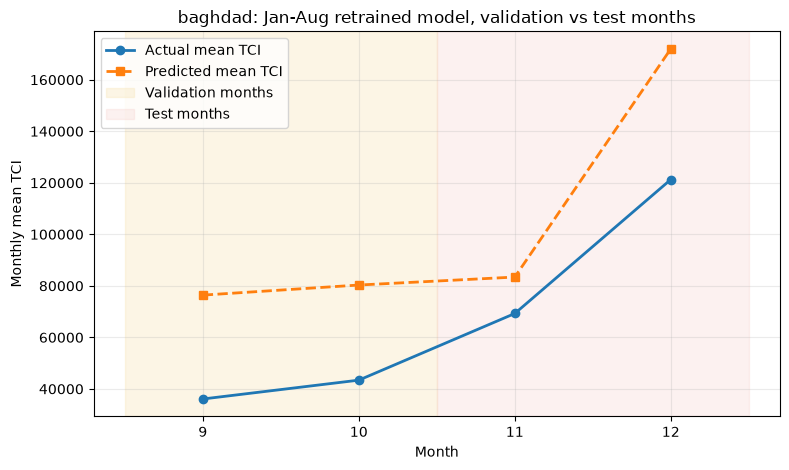

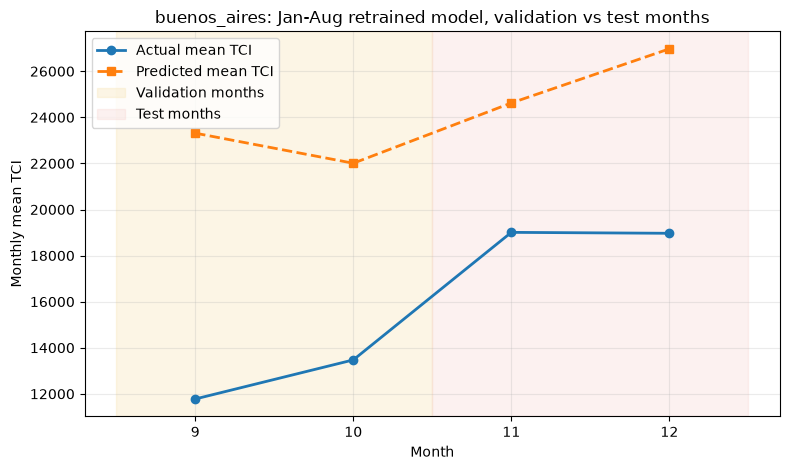

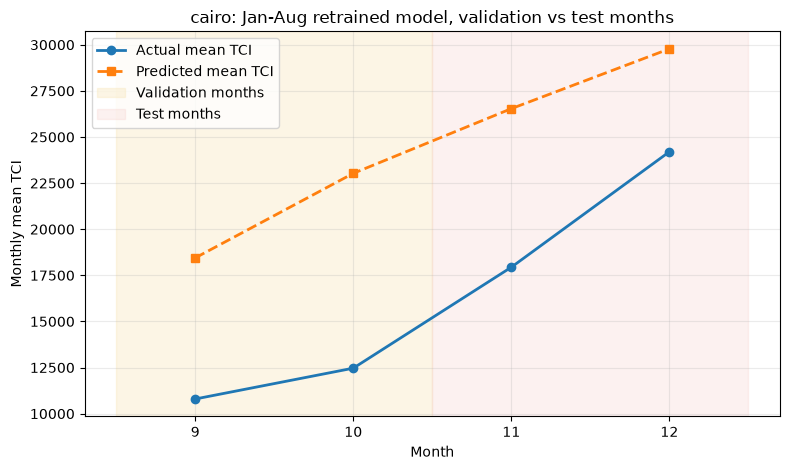

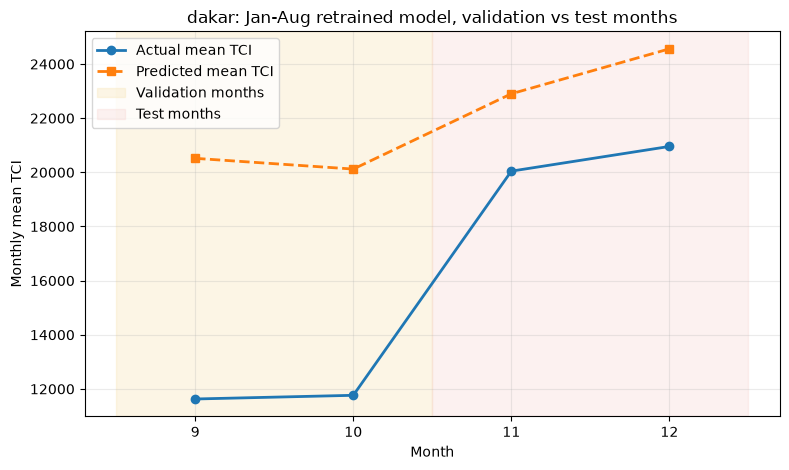

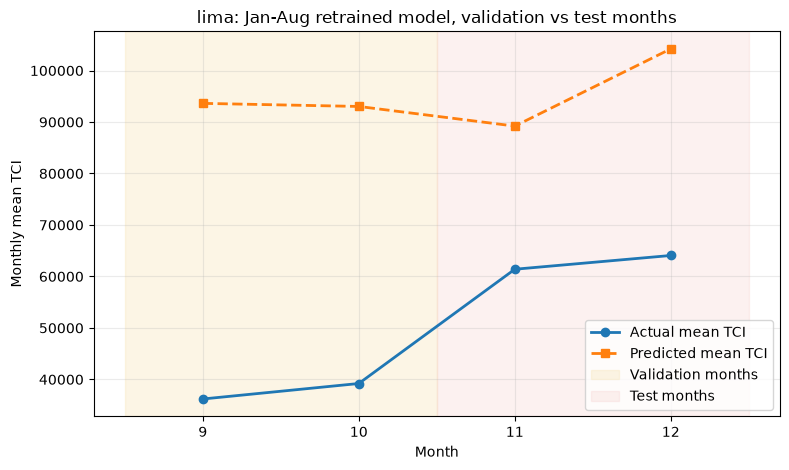

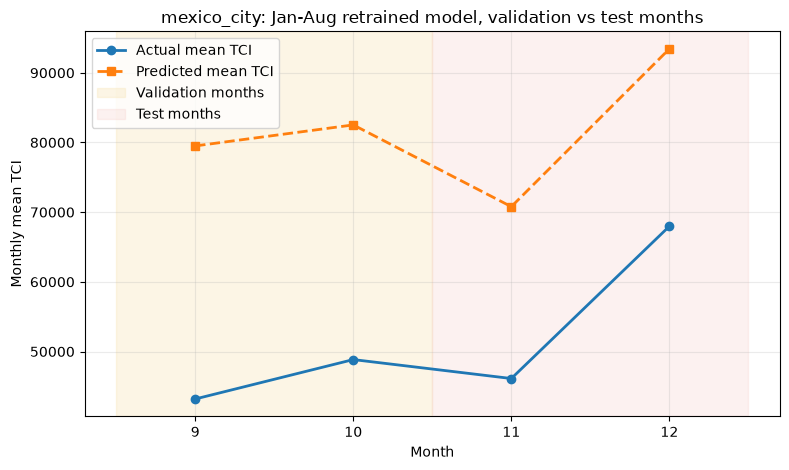

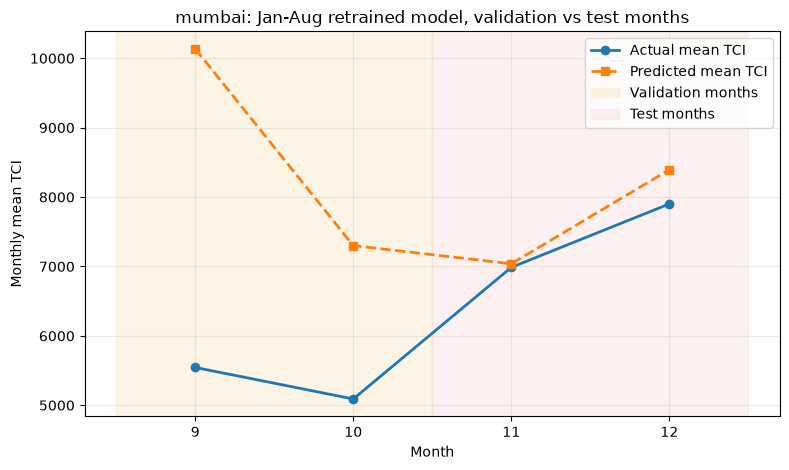

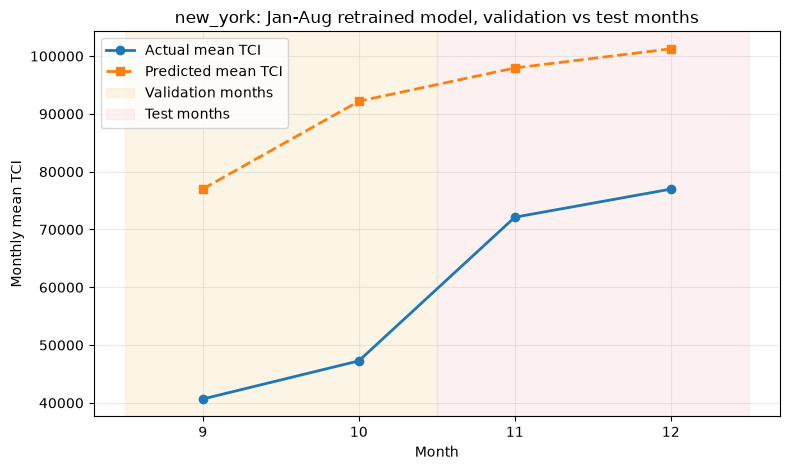

Saved summary: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/jan_aug_retrained_validation_vs_test_summary.csv
Saved monthly metrics: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/jan_aug_retrained_monthly_metrics.csv
Saved predictions: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/jan_aug_retrained_all_predictions.csv


,city,main_model_selected_model,validation_rmse_sep_oct_train_jan_aug_only,test_rmse_nov_dec_train_jan_aug_only,test_minus_validation_rmse,test_vs_validation_rmse_ratio,main_model_final_test_rmse_train_plus_validation,rmse_change_vs_main_model_final_refit
0,baghdad,random_forest,95586.587837,114940.045607,19353.457771,1.202470,108388.952473,6551.093135
1,buenos_aires,xgboost,31425.881163,24158.856158,-7267.025005,0.768757,14291.375276,9867.480882
2,cairo,xgboost,34614.798929,31346.955112,-3267.843817,0.905594,23057.718673,8289.236439
3,dakar,xgboost,18845.081440,14474.930200,-4370.151240,0.768101,13582.253987,892.676212
4,lima,random_forest,108041.590999,70273.805415,-37767.785584,0.650433,47790.104823,22483.700593
5,mexico_city,random_forest,65783.478797,56962.690842,-8820.787955,0.865912,30627.768125,26334.922717
6,mumbai,elastic_net,5610.461093,10952.448140,5341.987048,1.952148,10988.175606,-35.727466
7,new_york,random_forest,53757.591311,37121.007608,-16636.583703,0.690526,24153.921511,12967.086097


In [6]:
summary_rows = []
monthly_rows = []
all_prediction_frames = []

for city, selected in selected_artifacts.items():
    panel = engineered_city_panels[city].copy()
    feature_cols = selected["feature_cols"]
    missing_features = [col for col in feature_cols if col not in panel.columns]
    if missing_features:
        raise ValueError(f"{city}: selected main-model feature columns are missing: {missing_features}")

    model_panel = panel.dropna(subset=[TARGET_COL] + feature_cols).copy()
    model_panel = model_panel.loc[~model_panel[MONTH_COL].isin(EXCLUDED_MONTHS)].copy()

    train_df = model_panel.loc[model_panel[MONTH_COL].isin(TRAIN_MONTHS)].copy()
    validation_df = model_panel.loc[model_panel[MONTH_COL].isin(VALIDATION_MONTHS)].copy()
    test_df = model_panel.loc[model_panel[MONTH_COL].isin(TEST_MONTHS)].copy()

    if train_df.empty or validation_df.empty or test_df.empty:
        raise ValueError(
            f"{city}: one split is empty after filtering. "
            f"train={len(train_df)}, validation={len(validation_df)}, test={len(test_df)}"
        )

    model = build_model(selected["model_name"], selected["params"])
    model.fit(train_df[feature_cols], train_df[TARGET_COL])

    city_output_dir = OUTPUT_ROOT / city
    city_output_dir.mkdir(parents=True, exist_ok=True)

    split_frames = {
        "train_jan_aug": train_df,
        "validation_sep_oct": validation_df,
        "test_nov_dec": test_df,
    }

    city_metrics = {}
    for split_name, split_df in split_frames.items():
        pred = model.predict(split_df[feature_cols])
        metrics = evaluate_regression(split_df[TARGET_COL], pred)
        city_metrics[split_name] = metrics

        pred_cols = [CITY_COL, SPATIAL_ID_COL, YEAR_COL, MONTH_COL, TARGET_COL, "centroid_lon", "centroid_lat"]
        pred_df = add_prediction_outputs(split_df[pred_cols], pred)
        pred_df["evaluation_split"] = split_name
        pred_df["model_name"] = selected["model_name"]
        all_prediction_frames.append(pred_df)
        pred_df.to_csv(city_output_dir / f"{split_name}_predictions.csv", index=False)

        for month, month_df in pred_df.groupby(MONTH_COL):
            month_metrics = evaluate_regression(month_df[TARGET_COL], month_df[predicted_col()])
            monthly_rows.append({
                "city": city,
                "model_name": selected["model_name"],
                "evaluation_split": split_name,
                "month": int(month),
                **month_metrics,
            })

    main_metrics = selected.get("main_model_metrics", {})
    summary_row = {
        "city": city,
        "main_model_selected_model": selected["model_name"],
        "main_model_best_params": json.dumps(selected["params"], sort_keys=True),
        "feature_count": len(feature_cols),
        "train_months_used_for_this_diagnostic": month_label(TRAIN_MONTHS),
        "validation_months_evaluated": month_label(VALIDATION_MONTHS),
        "test_months_evaluated": month_label(TEST_MONTHS),
        "train_rmse_jan_aug": city_metrics["train_jan_aug"]["rmse"],
        "train_mae_jan_aug": city_metrics["train_jan_aug"]["mae"],
        "train_r2_jan_aug": city_metrics["train_jan_aug"]["r2"],
        "validation_rmse_sep_oct_train_jan_aug_only": city_metrics["validation_sep_oct"]["rmse"],
        "validation_mae_sep_oct_train_jan_aug_only": city_metrics["validation_sep_oct"]["mae"],
        "validation_r2_sep_oct_train_jan_aug_only": city_metrics["validation_sep_oct"]["r2"],
        "validation_bias_sep_oct_train_jan_aug_only": city_metrics["validation_sep_oct"]["bias_pred_minus_actual"],
        "test_rmse_nov_dec_train_jan_aug_only": city_metrics["test_nov_dec"]["rmse"],
        "test_mae_nov_dec_train_jan_aug_only": city_metrics["test_nov_dec"]["mae"],
        "test_r2_nov_dec_train_jan_aug_only": city_metrics["test_nov_dec"]["r2"],
        "test_bias_nov_dec_train_jan_aug_only": city_metrics["test_nov_dec"]["bias_pred_minus_actual"],
        "test_minus_validation_rmse": city_metrics["test_nov_dec"]["rmse"] - city_metrics["validation_sep_oct"]["rmse"],
        "test_vs_validation_rmse_ratio": city_metrics["test_nov_dec"]["rmse"] / city_metrics["validation_sep_oct"]["rmse"] if city_metrics["validation_sep_oct"]["rmse"] else np.nan,
        "main_model_final_test_rmse_train_plus_validation": main_metrics.get("test_rmse", np.nan),
        "main_model_final_test_mae_train_plus_validation": main_metrics.get("test_mae", np.nan),
        "main_model_final_test_r2_train_plus_validation": main_metrics.get("test_r2", np.nan),
        "rmse_change_vs_main_model_final_refit": city_metrics["test_nov_dec"]["rmse"] - main_metrics.get("test_rmse", np.nan),
    }
    summary_rows.append(summary_row)

    joblib.dump(
        {
            "city": city,
            "source_main_model_scenario": MAIN_MODEL_SCENARIO_ID,
            "diagnostic": "retrained_on_jan_aug_only",
            "model_name": selected["model_name"],
            "params": selected["params"],
            "feature_cols": feature_cols,
            "model": model,
            "metrics": summary_row,
        },
        city_output_dir / "jan_aug_retrained_model_artifact.joblib",
    )

    monthly_city = pd.DataFrame([row for row in monthly_rows if row["city"] == city]).sort_values("month")
    monthly_city.to_csv(city_output_dir / "monthly_validation_test_metrics.csv", index=False)

    fig, ax = plt.subplots(figsize=(8, 4.8))
    eval_months = monthly_city.loc[monthly_city["evaluation_split"].isin(["validation_sep_oct", "test_nov_dec"])]
    ax.plot(eval_months["month"], eval_months["actual_mean"], marker="o", linewidth=2, label="Actual mean TCI")
    ax.plot(eval_months["month"], eval_months["predicted_mean"], marker="s", linestyle="--", linewidth=2, label="Predicted mean TCI")
    ax.axvspan(8.5, 10.5, color="#F8E5B5", alpha=0.35, label="Validation months")
    ax.axvspan(10.5, 12.5, color="#F6C9C6", alpha=0.25, label="Test months")
    ax.set_xticks([9, 10, 11, 12])
    ax.set_xlabel("Month")
    ax.set_ylabel("Monthly mean TCI")
    ax.set_title(f"{city}: Jan-Aug retrained model, validation vs test months")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    fig.tight_layout()
    fig.savefig(city_output_dir / "jan_aug_retrained_validation_test_monthly_mean.png", dpi=220, bbox_inches="tight")
    plt.show()

summary_df = pd.DataFrame(summary_rows).sort_values("city")
monthly_df = pd.DataFrame(monthly_rows).sort_values(["city", "month"])
predictions_df = pd.concat(all_prediction_frames, ignore_index=True) if all_prediction_frames else pd.DataFrame()

summary_path = OUTPUT_ROOT / "jan_aug_retrained_validation_vs_test_summary.csv"
monthly_path = OUTPUT_ROOT / "jan_aug_retrained_monthly_metrics.csv"
predictions_path = OUTPUT_ROOT / "jan_aug_retrained_all_predictions.csv"
summary_df.to_csv(summary_path, index=False)
monthly_df.to_csv(monthly_path, index=False)
predictions_df.to_csv(predictions_path, index=False)

print("Saved summary:", summary_path)
print("Saved monthly metrics:", monthly_path)
print("Saved predictions:", predictions_path)

display(summary_df[[
    "city",
    "main_model_selected_model",
    "validation_rmse_sep_oct_train_jan_aug_only",
    "test_rmse_nov_dec_train_jan_aug_only",
    "test_minus_validation_rmse",
    "test_vs_validation_rmse_ratio",
    "main_model_final_test_rmse_train_plus_validation",
    "rmse_change_vs_main_model_final_refit",
]])




## 5. Cross-City Comparison

This section summarizes whether November-December is harder than September-October when every city model is trained only on January-August.

The key quantities are:

- September-October RMSE;
- November-December RMSE;
- the difference between the two periods;
- the ratio between test RMSE and validation-period RMSE.

If November-December error is much higher, the issue may be temporal transfer rather than only model tuning.


Cities where Nov-Dec RMSE is higher than Sep-Oct RMSE:


,city,main_model_selected_model,validation_rmse_sep_oct_train_jan_aug_only,test_rmse_nov_dec_train_jan_aug_only,test_minus_validation_rmse,test_vs_validation_rmse_ratio,test_harder_than_validation
0,baghdad,random_forest,95586.587837,114940.045607,19353.457771,1.202470,True
6,mumbai,elastic_net,5610.461093,10952.448140,5341.987048,1.952148,True
2,cairo,xgboost,34614.798929,31346.955112,-3267.843817,0.905594,False
3,dakar,xgboost,18845.081440,14474.930200,-4370.151240,0.768101,False
1,buenos_aires,xgboost,31425.881163,24158.856158,-7267.025005,0.768757,False
5,mexico_city,random_forest,65783.478797,56962.690842,-8820.787955,0.865912,False
7,new_york,random_forest,53757.591311,37121.007608,-16636.583703,0.690526,False
4,lima,random_forest,108041.590999,70273.805415,-37767.785584,0.650433,False



Average metrics across cities:


,mean_validation_rmse_sep_oct,mean_test_rmse_nov_dec,mean_test_minus_validation_rmse,median_test_minus_validation_rmse,cities_test_harder_count,cities_total
0,51708.183946,45028.842385,-6679.341561,-5818.588122,2,8


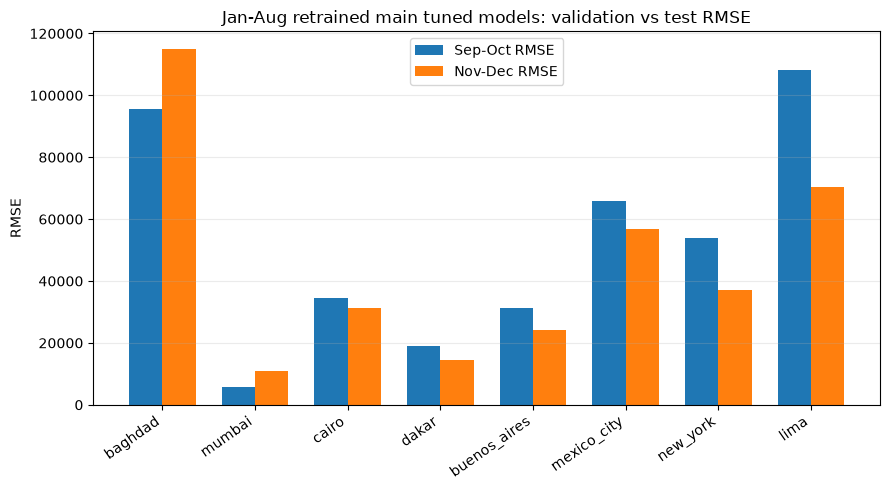

Saved figure: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/validation_vs_test_rmse_by_city.png


In [7]:
if summary_df.empty:
    print("No summary rows were created. Check whether main tuned model artifacts exist for the requested cities.")
else:
    comparison = summary_df.copy()
    comparison["test_harder_than_validation"] = comparison["test_minus_validation_rmse"] > 0
    comparison["test_improved_after_main_model_train_plus_validation_refit"] = comparison["rmse_change_vs_main_model_final_refit"] > 0

    print("Cities where Nov-Dec RMSE is higher than Sep-Oct RMSE:")
    display(comparison[[
        "city",
        "main_model_selected_model",
        "validation_rmse_sep_oct_train_jan_aug_only",
        "test_rmse_nov_dec_train_jan_aug_only",
        "test_minus_validation_rmse",
        "test_vs_validation_rmse_ratio",
        "test_harder_than_validation",
    ]].sort_values("test_minus_validation_rmse", ascending=False))

    print()
    print("Average metrics across cities:")
    aggregate = pd.DataFrame([
        {
            "mean_validation_rmse_sep_oct": comparison["validation_rmse_sep_oct_train_jan_aug_only"].mean(),
            "mean_test_rmse_nov_dec": comparison["test_rmse_nov_dec_train_jan_aug_only"].mean(),
            "mean_test_minus_validation_rmse": comparison["test_minus_validation_rmse"].mean(),
            "median_test_minus_validation_rmse": comparison["test_minus_validation_rmse"].median(),
            "cities_test_harder_count": int(comparison["test_harder_than_validation"].sum()),
            "cities_total": len(comparison),
        }
    ])
    display(aggregate)

    fig, ax = plt.subplots(figsize=(9, 5))
    plot_df = comparison.sort_values("test_minus_validation_rmse", ascending=False)
    x = np.arange(len(plot_df))
    width = 0.36
    ax.bar(x - width/2, plot_df["validation_rmse_sep_oct_train_jan_aug_only"], width, label="Sep-Oct RMSE")
    ax.bar(x + width/2, plot_df["test_rmse_nov_dec_train_jan_aug_only"], width, label="Nov-Dec RMSE")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["city"], rotation=35, ha="right")
    ax.set_ylabel("RMSE")
    ax.set_title("Jan-Aug retrained main tuned models: validation vs test RMSE")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig_path = OUTPUT_ROOT / "validation_vs_test_rmse_by_city.png"
    fig.savefig(fig_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved figure:", fig_path)




 ## 6. Diagnostic Checks: Why Do Some Periods Behave Differently?

The previous section fixes the selected model type and hyperparameters, then retrains on January-August only. The diagnostics below ask whether September-October and November-December behave differently because:

- the target distribution changes;
- dynamic predictors such as NO₂, temperature, wind, or holidays shift;
- errors are concentrated in one month;
- the model relies on feature groups that do not transfer well across periods.

The code runs for all available cities and highlights selected cities only for plots where showing every city would be too crowded.


In [8]:
from sklearn.inspection import permutation_importance

DIAGNOSTIC_CITIES = [city for city in ["mexico_city", "lima", "baghdad"] if city in selected_artifacts]
if not DIAGNOSTIC_CITIES:
    DIAGNOSTIC_CITIES = list(selected_artifacts)

PERIOD_DEFINITIONS = {
    "train_jan_aug": TRAIN_MONTHS,
    "validation_sep_oct": VALIDATION_MONTHS,
    "test_nov_dec": TEST_MONTHS,
}

DYNAMIC_DIAGNOSTIC_COLS = [
    TARGET_COL,
    "no2",
    "era5_temp",
    "wind_speed",
    "holiday_is_off_days",
]
DYNAMIC_DIAGNOSTIC_COLS = [
    col for col in DYNAMIC_DIAGNOSTIC_COLS
    if any(col in panel.columns for panel in engineered_city_panels.values())
]

DIAGNOSTIC_OUTPUT_DIR = OUTPUT_ROOT / "diagnostics"
DIAGNOSTIC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Diagnostic cities:", DIAGNOSTIC_CITIES)
print("Diagnostic variables:", DYNAMIC_DIAGNOSTIC_COLS)
print("Diagnostic output directory:", DIAGNOSTIC_OUTPUT_DIR)




Diagnostic cities: ['mexico_city', 'lima', 'baghdad']
Diagnostic variables: ['tci', 'no2', 'era5_temp', 'wind_speed', 'holiday_is_off_days']
Diagnostic output directory: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics


### 6.1 Period-Level Distribution Diagnostics

This table compares the target and dynamic predictors across January-August, September-October, and November-December.

Large changes in the mean, spread, or quantiles suggest that the model is being evaluated on a different data regime from the one used for training.


In [9]:
distribution_rows = []

for city, selected in selected_artifacts.items():
    panel = engineered_city_panels[city].copy()
    feature_cols = selected["feature_cols"]
    required_cols = [TARGET_COL] + [col for col in feature_cols if col in panel.columns]
    model_panel = panel.dropna(subset=required_cols).copy()
    model_panel = model_panel.loc[~model_panel[MONTH_COL].isin(EXCLUDED_MONTHS)].copy()

    for period_name, months in PERIOD_DEFINITIONS.items():
        period_df = model_panel.loc[model_panel[MONTH_COL].isin(months)].copy()
        base_row = {
            "city": city,
            "period": period_name,
            "months": month_label(months),
            "rows": len(period_df),
            "spatial_ids": period_df[SPATIAL_ID_COL].nunique(),
        }
        for col in DYNAMIC_DIAGNOSTIC_COLS:
            if col not in period_df.columns or period_df.empty:
                continue
            values = period_df[col].dropna()
            base_row[f"{col}_mean"] = values.mean()
            base_row[f"{col}_sd"] = values.std()
            base_row[f"{col}_q10"] = values.quantile(0.10)
            base_row[f"{col}_median"] = values.quantile(0.50)
            base_row[f"{col}_q90"] = values.quantile(0.90)
        distribution_rows.append(base_row)

distribution_diagnostics = pd.DataFrame(distribution_rows).sort_values(["city", "period"])
distribution_path = DIAGNOSTIC_OUTPUT_DIR / "period_distribution_diagnostics.csv"
distribution_diagnostics.to_csv(distribution_path, index=False)
print("Saved distribution diagnostics:", distribution_path)
display(distribution_diagnostics)




Saved distribution diagnostics: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/period_distribution_diagnostics.csv


,city,period,months,rows,spatial_ids,tci_mean,tci_sd,tci_q10,tci_median,tci_q90,...,wind_speed_mean,wind_speed_sd,wind_speed_q10,wind_speed_median,wind_speed_q90,holiday_is_off_days_mean,holiday_is_off_days_sd,holiday_is_off_days_q10,holiday_is_off_days_median,holiday_is_off_days_q90
2,baghdad,test_nov_dec,"11,12",5281,3161,90274.980326,217611.823843,3699.633968,13693.830456,246637.535687,...,2.471374,0.195691,2.263285,2.420437,2.758104,9.403901,0.490725,9.0,9.0,10.0
0,baghdad,train_jan_aug,"1,2,3,4,5,6,7,8",17337,3426,118529.016309,335610.231166,4372.337499,15350.419083,292966.236584,...,2.786251,0.665969,2.080690,2.534422,3.821660,11.044125,1.513766,8.0,11.0,13.0
1,baghdad,validation_sep_oct,"9,10",5976,3230,39725.715411,105423.348349,2535.460694,7812.378554,91032.835006,...,2.703566,0.249709,2.423180,2.677538,3.012533,9.000000,0.000000,9.0,9.0,9.0
5,buenos_aires,test_nov_dec,"11,12",5803,3094,18988.835527,45829.716748,1121.804626,5064.041299,44099.848496,...,2.823737,0.279805,2.560347,2.705095,3.239511,10.526452,0.499343,10.0,11.0,11.0
3,buenos_aires,train_jan_aug,"1,2,3,4,5,6,7,8",19136,3569,23108.085259,59835.550614,1272.885990,5821.031078,53852.065246,...,3.044226,0.344152,2.674432,2.982625,3.539720,10.131480,1.564654,8.0,10.0,13.0
4,buenos_aires,validation_sep_oct,"9,10",5832,3059,12618.180081,26627.511905,972.070597,4400.376117,30647.079816,...,3.416512,0.456062,2.855558,3.523409,4.074972,8.496399,0.500030,8.0,8.0,9.0
8,cairo,test_nov_dec,"11,12",4019,2319,20679.422093,61039.615713,1524.732686,5822.899938,40712.473647,...,2.596302,0.347064,2.162375,2.611826,3.086691,8.562329,0.496162,8.0,9.0,9.0
6,cairo,train_jan_aug,"1,2,3,4,5,6,7,8",13879,2786,24936.720914,86423.279303,1634.250128,6762.168810,41758.152998,...,2.957904,0.437747,2.417709,2.940466,3.491363,11.199222,1.931530,8.0,11.0,14.0
7,cairo,validation_sep_oct,"9,10",4139,2289,11591.149851,30893.048800,1276.569609,4405.375392,22182.744966,...,2.891207,0.373229,2.398128,2.918102,3.352557,9.951921,0.998964,9.0,9.0,11.0
11,dakar,test_nov_dec,"11,12",505,277,20519.398763,33190.796343,1391.398524,6676.750955,57897.490936,...,5.982335,0.923874,4.869513,6.329335,7.174853,9.479208,0.500063,9.0,9.0,10.0


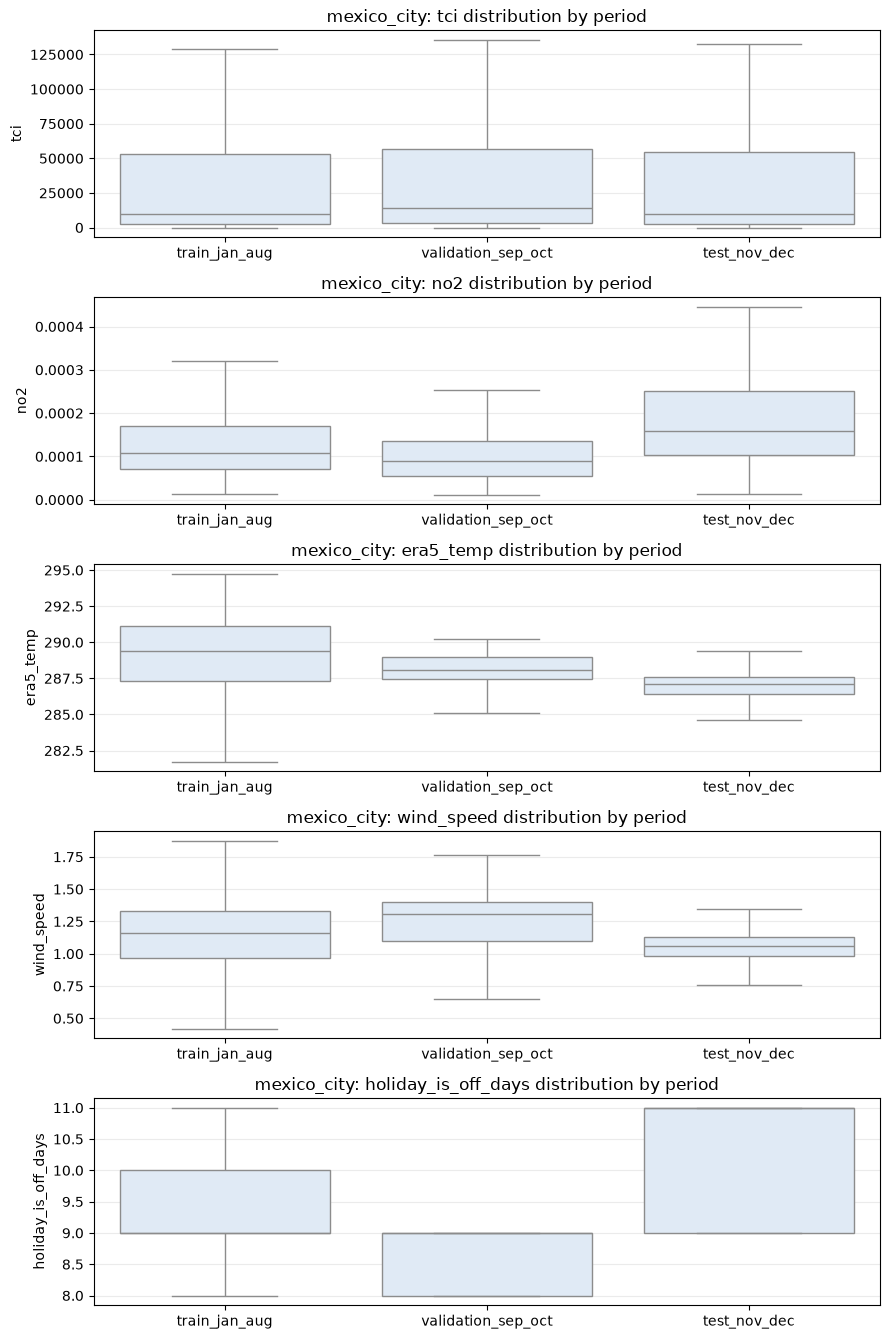

Saved period distribution plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/mexico_city_period_dynamic_variable_boxplots.png


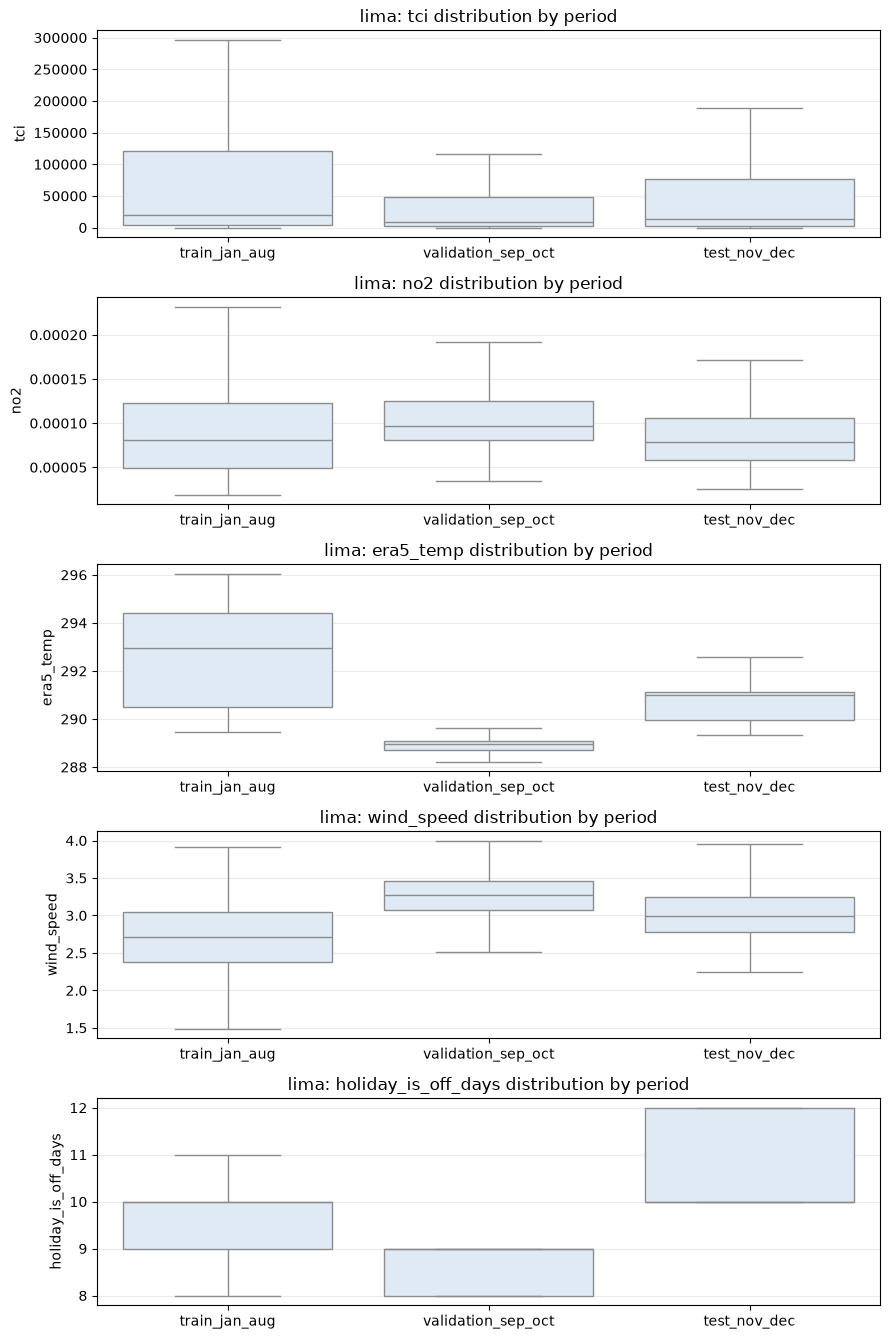

Saved period distribution plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/lima_period_dynamic_variable_boxplots.png


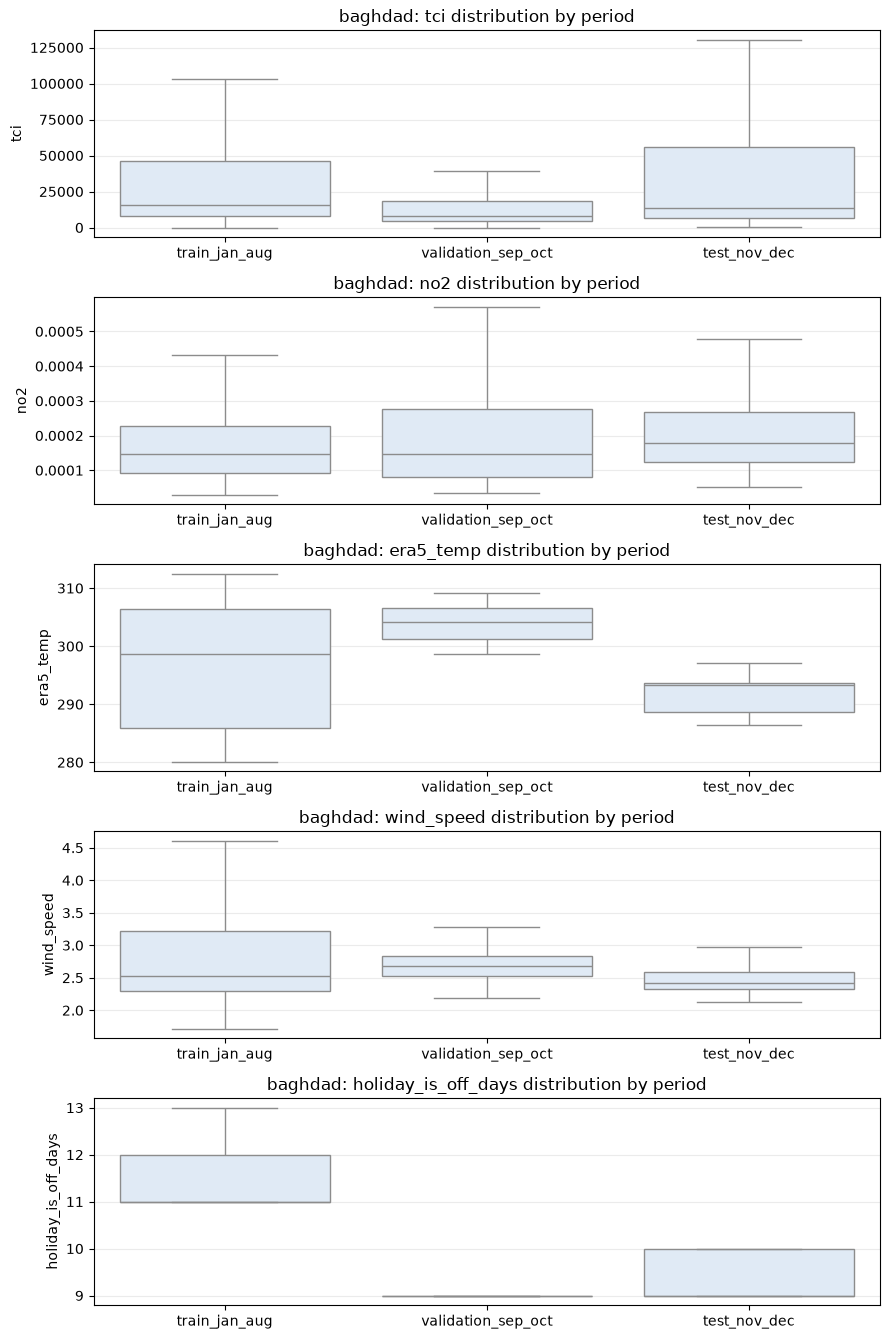

Saved period distribution plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/baghdad_period_dynamic_variable_boxplots.png


In [10]:
for city in DIAGNOSTIC_CITIES:
    selected = selected_artifacts[city]
    panel = engineered_city_panels[city].copy()
    feature_cols = selected["feature_cols"]
    required_cols = [TARGET_COL] + [col for col in feature_cols if col in panel.columns]
    plot_panel = panel.dropna(subset=required_cols).copy()
    plot_panel = plot_panel.loc[~plot_panel[MONTH_COL].isin(EXCLUDED_MONTHS)].copy()

    period_lookup = {}
    for period_name, months in PERIOD_DEFINITIONS.items():
        for month in months:
            period_lookup[month] = period_name
    plot_panel["diagnostic_period"] = plot_panel[MONTH_COL].map(period_lookup)
    plot_panel = plot_panel.dropna(subset=["diagnostic_period"])

    plot_cols = [col for col in DYNAMIC_DIAGNOSTIC_COLS if col in plot_panel.columns]
    if not plot_cols:
        continue

    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(9, 2.7 * len(plot_cols)), sharex=False)
    if len(plot_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_cols):
        sns.boxplot(
            data=plot_panel,
            x="diagnostic_period",
            y=col,
            order=list(PERIOD_DEFINITIONS.keys()),
            ax=ax,
            color="#DCEAF8",
            showfliers=False,
        )
        ax.set_title(f"{city}: {col} distribution by period")
        ax.set_xlabel("")
        ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig_path = DIAGNOSTIC_OUTPUT_DIR / f"{city}_period_dynamic_variable_boxplots.png"
    fig.savefig(fig_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved period distribution plot:", fig_path)




### 6.2 Monthly Error Diagnostics

This section keeps month-level metrics visible.

If one month dominates the error, the problem is likely period-specific rather than a general failure of the selected model. This is especially useful when September-October and November-December have very different target distributions.


Saved monthly error diagnostics: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/monthly_error_diagnostics.csv


,city,model_name,evaluation_split,month,rows,rmse,mae,r2,actual_mean,predicted_mean,bias_pred_minus_actual,abs_bias
0,baghdad,random_forest,train_jan_aug,1,2732,139929.057466,58156.794017,0.907724,186036.275905,171451.200061,-14585.075844,14585.075844
1,baghdad,random_forest,train_jan_aug,2,2746,148792.256454,60320.755999,0.906884,186555.736448,177129.622148,-9426.114301,9426.114301
2,baghdad,random_forest,train_jan_aug,3,2788,106240.791074,45673.919444,0.908436,146164.304520,153085.317504,6921.012985,6921.012985
3,baghdad,random_forest,train_jan_aug,4,2961,64621.013680,28133.856506,0.907288,78219.905643,79312.514991,1092.609348,1092.609348
4,baghdad,random_forest,train_jan_aug,5,3089,63728.007344,26661.742653,0.908749,77802.299059,75451.151518,-2351.147541,2351.147541
...,...,...,...,...,...,...,...,...,...,...,...,...
75,new_york,random_forest,train_jan_aug,6,738,18166.357227,15010.717598,0.905241,57658.083472,72233.789460,14575.705988,14575.705988
76,new_york,random_forest,validation_sep_oct,9,738,47723.588417,36679.855274,-0.019172,40677.110185,77014.801491,36337.691306,36337.691306
77,new_york,random_forest,validation_sep_oct,10,734,59207.713569,44983.225892,-0.256671,47268.655976,92186.069558,44917.413583,44917.413583
78,new_york,random_forest,test_nov_dec,11,736,36495.442826,27044.326693,0.797098,72126.114883,97944.982372,25818.867489,25818.867489


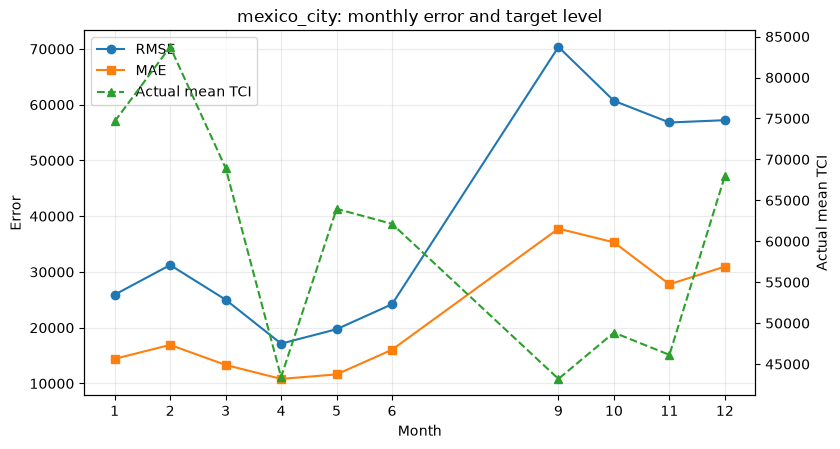

Saved monthly error plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/mexico_city_monthly_error_diagnostics.png


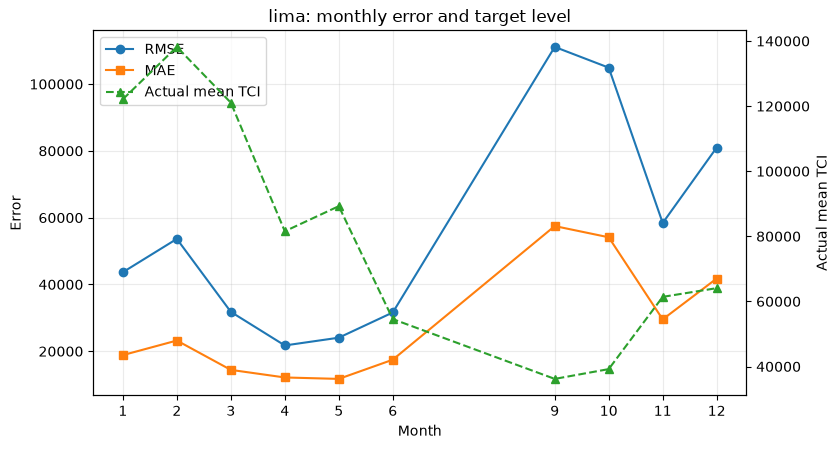

Saved monthly error plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/lima_monthly_error_diagnostics.png


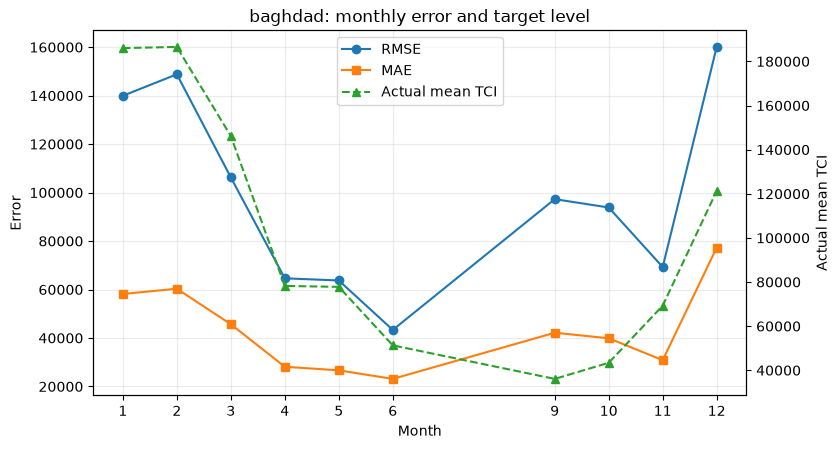

Saved monthly error plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/baghdad_monthly_error_diagnostics.png


In [11]:
if monthly_df.empty:
    print("monthly_df is empty. Run the retraining/evaluation cell first.")
else:
    monthly_error_view = monthly_df.copy()
    monthly_error_view["abs_bias"] = monthly_error_view["bias_pred_minus_actual"].abs()
    monthly_error_path = DIAGNOSTIC_OUTPUT_DIR / "monthly_error_diagnostics.csv"
    monthly_error_view.to_csv(monthly_error_path, index=False)
    print("Saved monthly error diagnostics:", monthly_error_path)
    display(monthly_error_view.sort_values(["city", "month"])[[
        "city", "model_name", "evaluation_split", "month", "rows",
        "rmse", "mae", "r2", "actual_mean", "predicted_mean",
        "bias_pred_minus_actual", "abs_bias",
    ]])

    for city in DIAGNOSTIC_CITIES:
        city_monthly = monthly_error_view.loc[monthly_error_view["city"] == city].sort_values("month")
        if city_monthly.empty:
            continue
        fig, ax1 = plt.subplots(figsize=(8.5, 4.6))
        ax1.plot(city_monthly["month"], city_monthly["rmse"], marker="o", label="RMSE", color="#1f77b4")
        ax1.plot(city_monthly["month"], city_monthly["mae"], marker="s", label="MAE", color="#ff7f0e")
        ax1.set_xlabel("Month")
        ax1.set_ylabel("Error")
        ax1.set_xticks(city_monthly["month"].tolist())
        ax1.grid(alpha=0.25)
        ax2 = ax1.twinx()
        ax2.plot(city_monthly["month"], city_monthly["actual_mean"], marker="^", linestyle="--", label="Actual mean TCI", color="#2ca02c")
        ax2.set_ylabel("Actual mean TCI")
        handles1, labels1 = ax1.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(handles1 + handles2, labels1 + labels2, loc="best")
        ax1.set_title(f"{city}: monthly error and target level")
        fig.tight_layout()
        fig_path = DIAGNOSTIC_OUTPUT_DIR / f"{city}_monthly_error_diagnostics.png"
        fig.savefig(fig_path, dpi=220, bbox_inches="tight")
        plt.show()
        print("Saved monthly error plot:", fig_path)




### 6.3 Period-Specific Permutation Importance

The selected model is trained on January-August only. Permutation importance is then computed separately for January-August, September-October, and November-December.

A feature that is important in training but not in later periods, or important only in the test period, may indicate that the learned relationship is not stable over time.

Permutation importance is model-agnostic, so it works for Elastic Net, Random Forest, HistGradientBoosting, and XGBoost. The reported value is the increase in RMSE when one feature is randomly permuted.



Permutation importance for mexico_city (random_forest)


,city,model_name,period,months,feature,increase_rmse_mean,increase_rmse_sd,sample_rows
8,mexico_city,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",building_height,25752.925209,212.032322,3000
0,mexico_city,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",no2,19208.531926,494.412772,3000
22,mexico_city,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",poi_commercial_n_commercial,15519.076151,366.292980,3000
39,mexico_city,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",road_length_residential_m_share,12299.436819,488.652218,3000
35,mexico_city,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",poi_total,11467.563438,288.547364,3000
36,mexico_city,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",log_poi_total,11230.101616,261.948344,3000
7,mexico_city,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",population,10142.451740,178.712336,3000
31,mexico_city,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",log_population,9352.571292,159.338131,3000
14,mexico_city,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",road_length_primary_m,8593.819987,285.207355,3000
38,mexico_city,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",road_length_primary_m_share,7279.788478,307.804230,3000


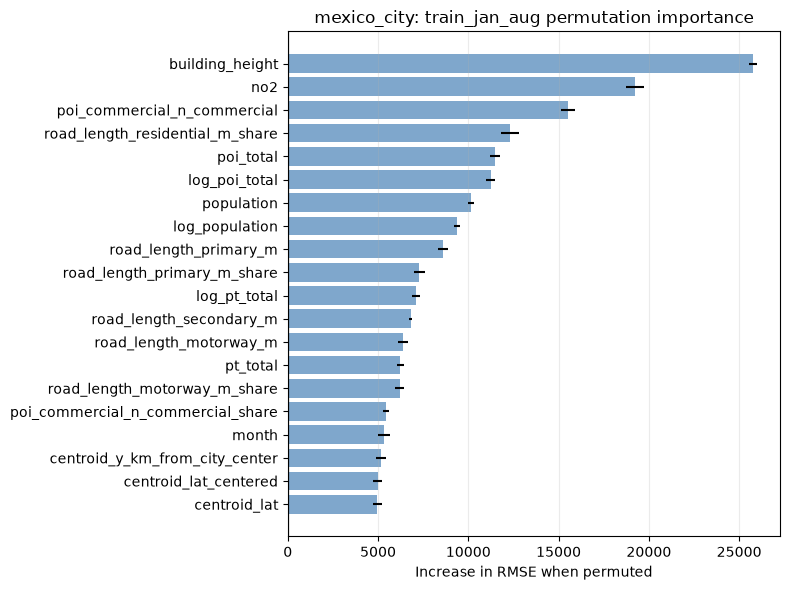

Saved permutation importance plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/mexico_city_train_jan_aug_permutation_importance.png


,city,model_name,period,months,feature,increase_rmse_mean,increase_rmse_sd,sample_rows
1,mexico_city,random_forest,validation_sep_oct,"9,10",era5_temp,7.246727e+02,2.878378e+02,3000
5,mexico_city,random_forest,validation_sep_oct,"9,10",holiday_is_off_days,1.987285e+01,4.072703e+01,3000
10,mexico_city,random_forest,validation_sep_oct,"9,10",pt_count_lines,1.259162e+01,1.960184e+00,3000
47,mexico_city,random_forest,validation_sep_oct,"9,10",poi_leisure_n_leisure_share,1.014699e+01,1.943717e+01,3000
25,mexico_city,random_forest,validation_sep_oct,"9,10",power_plant_n_power_plant,1.893441e+00,7.017664e-04,3000
34,mexico_city,random_forest,validation_sep_oct,"9,10",log_power_plant_n_power_plant,9.817299e-01,4.502774e-03,3000
2,mexico_city,random_forest,validation_sep_oct,"9,10",month,-1.455192e-12,2.910383e-12,3000
6,mexico_city,random_forest,validation_sep_oct,"9,10",wind_speed,-8.271731e+01,1.048716e+02,3000
15,mexico_city,random_forest,validation_sep_oct,"9,10",road_length_residential_m,-1.424074e+02,2.432545e+02,3000
41,mexico_city,random_forest,validation_sep_oct,"9,10",road_length_tertiary_m_share,-2.950242e+02,5.962339e+01,3000


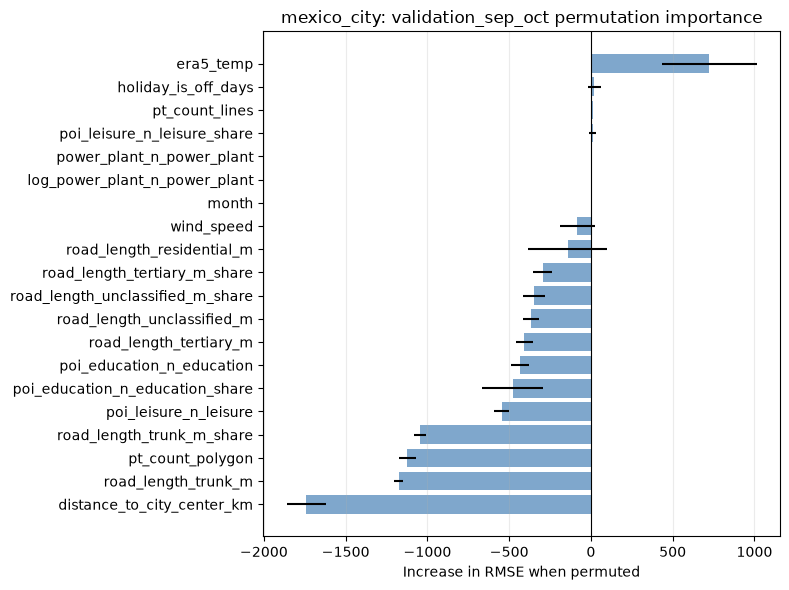

Saved permutation importance plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/mexico_city_validation_sep_oct_permutation_importance.png


,city,model_name,period,months,feature,increase_rmse_mean,increase_rmse_sd,sample_rows
15,mexico_city,random_forest,test_nov_dec,"11,12",road_length_residential_m,5.513215e+02,2.279629e+02,3000
6,mexico_city,random_forest,test_nov_dec,"11,12",wind_speed,4.200345e+02,7.621544e+01,3000
47,mexico_city,random_forest,test_nov_dec,"11,12",poi_leisure_n_leisure_share,3.506594e+02,5.099228e+01,3000
5,mexico_city,random_forest,test_nov_dec,"11,12",holiday_is_off_days,1.408607e+02,7.865438e+01,3000
46,mexico_city,random_forest,test_nov_dec,"11,12",poi_education_n_education_share,9.307102e+01,9.756974e+01,3000
10,mexico_city,random_forest,test_nov_dec,"11,12",pt_count_lines,3.382816e+01,8.497188e-01,3000
2,mexico_city,random_forest,test_nov_dec,"11,12",month,-1.455192e-12,2.910383e-12,3000
34,mexico_city,random_forest,test_nov_dec,"11,12",log_power_plant_n_power_plant,-2.910383e-12,3.564477e-12,3000
25,mexico_city,random_forest,test_nov_dec,"11,12",power_plant_n_power_plant,-2.910383e-12,3.564477e-12,3000
41,mexico_city,random_forest,test_nov_dec,"11,12",road_length_tertiary_m_share,-2.086836e+02,6.841561e+01,3000


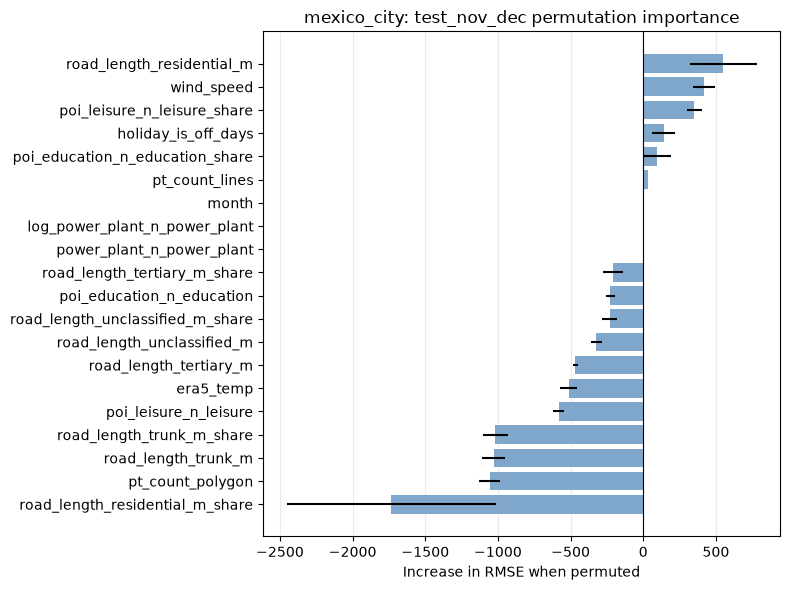

Saved permutation importance plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/mexico_city_test_nov_dec_permutation_importance.png

Permutation importance for lima (random_forest)


,city,model_name,period,months,feature,increase_rmse_mean,increase_rmse_sd,sample_rows
30,lima,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",distance_to_city_center_km,63493.637404,1500.987056,3000
35,lima,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",poi_total,48003.529711,2600.993656,3000
39,lima,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",road_length_residential_m_share,46537.455667,1334.723321,3000
36,lima,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",log_poi_total,41736.806321,2345.572025,3000
13,lima,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",road_length_motorway_m,20969.074226,1058.716701,3000
6,lima,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",wind_speed,15146.712764,454.289220,3000
14,lima,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",road_length_primary_m,14461.549072,456.989555,3000
8,lima,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",building_height,13628.891728,1049.680855,3000
21,lima,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",poi_business_n_business,10983.029758,296.230150,3000
0,lima,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",no2,9105.339018,563.293553,3000


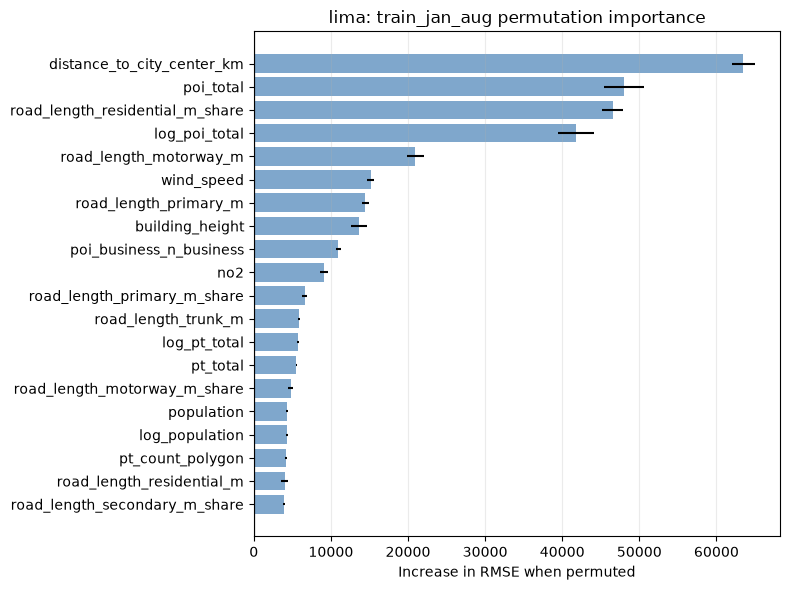

Saved permutation importance plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/lima_train_jan_aug_permutation_importance.png


,city,model_name,period,months,feature,increase_rmse_mean,increase_rmse_sd,sample_rows
6,lima,random_forest,validation_sep_oct,"9,10",wind_speed,4219.636754,590.312296,1826
0,lima,random_forest,validation_sep_oct,"9,10",no2,3091.358609,649.237517,1826
1,lima,random_forest,validation_sep_oct,"9,10",era5_temp,21.447412,3.349405,1826
34,lima,random_forest,validation_sep_oct,"9,10",log_power_plant_n_power_plant,1.317691,0.000583,1826
5,lima,random_forest,validation_sep_oct,"9,10",holiday_is_off_days,1.169242,2.812070,1826
2,lima,random_forest,validation_sep_oct,"9,10",month,0.000000,0.000000,1826
25,lima,random_forest,validation_sep_oct,"9,10",power_plant_n_power_plant,-0.016006,0.001121,1826
23,lima,random_forest,validation_sep_oct,"9,10",poi_education_n_education,-11.352429,75.151003,1826
18,lima,random_forest,validation_sep_oct,"9,10",road_length_trunk_m,-23.698105,76.927972,1826
43,lima,random_forest,validation_sep_oct,"9,10",road_length_unclassified_m_share,-117.872607,15.595908,1826


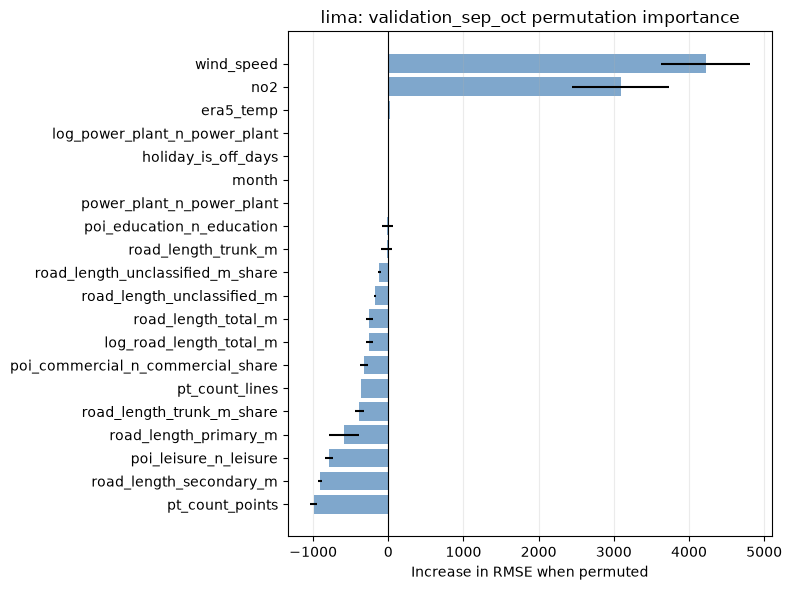

Saved permutation importance plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/lima_validation_sep_oct_permutation_importance.png


,city,model_name,period,months,feature,increase_rmse_mean,increase_rmse_sd,sample_rows
6,lima,random_forest,test_nov_dec,"11,12",wind_speed,7.310887e+03,9.651829e+02,1886
30,lima,random_forest,test_nov_dec,"11,12",distance_to_city_center_km,6.875922e+03,2.592269e+03,1886
0,lima,random_forest,test_nov_dec,"11,12",no2,6.278764e+03,8.440872e+02,1886
13,lima,random_forest,test_nov_dec,"11,12",road_length_motorway_m,2.026204e+03,9.852976e+02,1886
14,lima,random_forest,test_nov_dec,"11,12",road_length_primary_m,1.750867e+03,2.245508e+02,1886
18,lima,random_forest,test_nov_dec,"11,12",road_length_trunk_m,1.171504e+03,1.045453e+02,1886
23,lima,random_forest,test_nov_dec,"11,12",poi_education_n_education,1.205298e+02,6.850428e+01,1886
19,lima,random_forest,test_nov_dec,"11,12",road_length_unclassified_m,8.430829e+00,4.420295e+01,1886
1,lima,random_forest,test_nov_dec,"11,12",era5_temp,5.253348e+00,1.488224e+01,1886
34,lima,random_forest,test_nov_dec,"11,12",log_power_plant_n_power_plant,1.270184e+00,3.582867e-04,1886


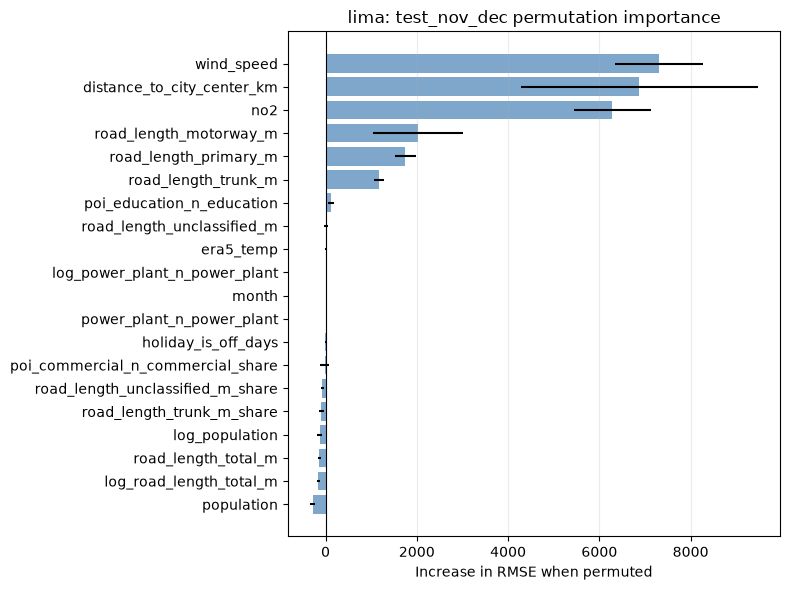

Saved permutation importance plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/lima_test_nov_dec_permutation_importance.png

Permutation importance for baghdad (random_forest)


,city,model_name,period,months,feature,increase_rmse_mean,increase_rmse_sd,sample_rows
36,baghdad,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",log_poi_total,80963.193568,2929.238172,3000
35,baghdad,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",poi_total,70765.465671,2521.497552,3000
1,baghdad,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",era5_temp,49090.317400,4406.171916,3000
30,baghdad,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",distance_to_city_center_km,48350.100418,4538.751459,3000
22,baghdad,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",poi_commercial_n_commercial,32415.412514,2206.098344,3000
2,baghdad,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",month,17302.863758,2035.400736,3000
8,baghdad,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",building_height,17054.471803,1866.427004,3000
31,baghdad,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",log_population,13548.673786,1943.655883,3000
7,baghdad,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",population,13168.270105,1967.052123,3000
39,baghdad,random_forest,train_jan_aug,"1,2,3,4,5,6,7,8",road_length_residential_m_share,10031.210139,922.802583,3000


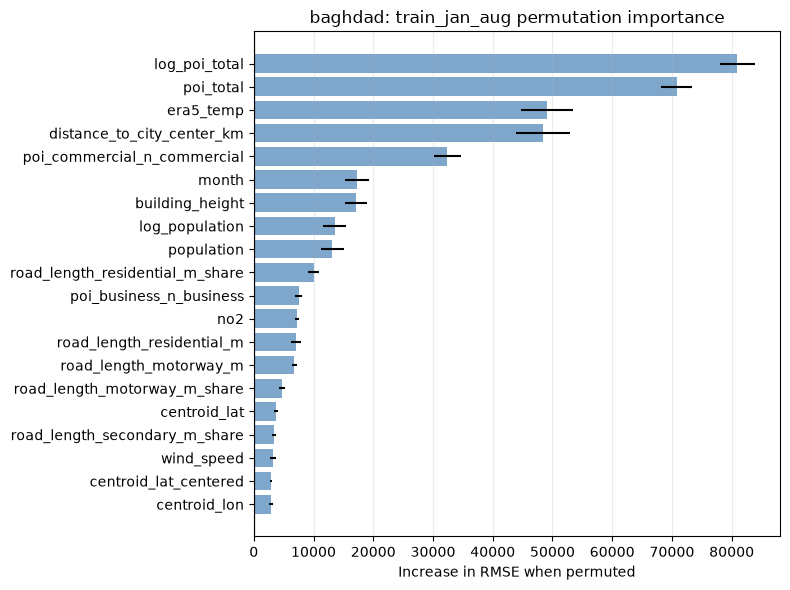

Saved permutation importance plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/baghdad_train_jan_aug_permutation_importance.png


,city,model_name,period,months,feature,increase_rmse_mean,increase_rmse_sd,sample_rows
15,baghdad,random_forest,validation_sep_oct,"9,10",road_length_residential_m,5.852644e+03,2.340068e+02,3000
39,baghdad,random_forest,validation_sep_oct,"9,10",road_length_residential_m_share,5.138208e+03,3.236387e+02,3000
7,baghdad,random_forest,validation_sep_oct,"9,10",population,4.352038e+03,5.819995e+02,3000
31,baghdad,random_forest,validation_sep_oct,"9,10",log_population,2.904446e+03,5.029173e+02,3000
20,baghdad,random_forest,validation_sep_oct,"9,10",road_length_total_m,2.591810e+03,1.363504e+02,3000
33,baghdad,random_forest,validation_sep_oct,"9,10",log_road_length_total_m,2.434616e+03,1.209282e+02,3000
6,baghdad,random_forest,validation_sep_oct,"9,10",wind_speed,2.295570e+03,2.307495e+02,3000
1,baghdad,random_forest,validation_sep_oct,"9,10",era5_temp,1.225787e+03,2.878313e+02,3000
46,baghdad,random_forest,validation_sep_oct,"9,10",poi_education_n_education_share,1.101110e+03,2.520741e+02,3000
43,baghdad,random_forest,validation_sep_oct,"9,10",road_length_unclassified_m_share,6.501857e+02,6.959159e+01,3000


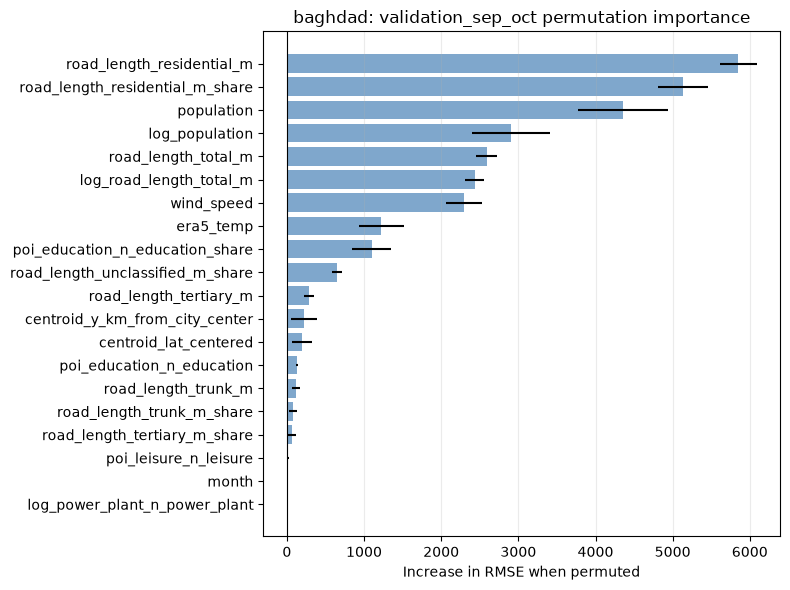

Saved permutation importance plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/baghdad_validation_sep_oct_permutation_importance.png


,city,model_name,period,months,feature,increase_rmse_mean,increase_rmse_sd,sample_rows
7,baghdad,random_forest,test_nov_dec,"11,12",population,11846.497826,404.195794,3000
39,baghdad,random_forest,test_nov_dec,"11,12",road_length_residential_m_share,11470.470367,787.867378,3000
15,baghdad,random_forest,test_nov_dec,"11,12",road_length_residential_m,10619.454620,250.938279,3000
31,baghdad,random_forest,test_nov_dec,"11,12",log_population,10542.003640,509.386344,3000
36,baghdad,random_forest,test_nov_dec,"11,12",log_poi_total,6229.854727,1166.904717,3000
33,baghdad,random_forest,test_nov_dec,"11,12",log_road_length_total_m,3025.513767,66.063254,3000
20,baghdad,random_forest,test_nov_dec,"11,12",road_length_total_m,2778.853733,64.051093,3000
46,baghdad,random_forest,test_nov_dec,"11,12",poi_education_n_education_share,2460.983280,191.544516,3000
13,baghdad,random_forest,test_nov_dec,"11,12",road_length_motorway_m,1910.332375,183.001980,3000
43,baghdad,random_forest,test_nov_dec,"11,12",road_length_unclassified_m_share,1773.669645,221.072752,3000


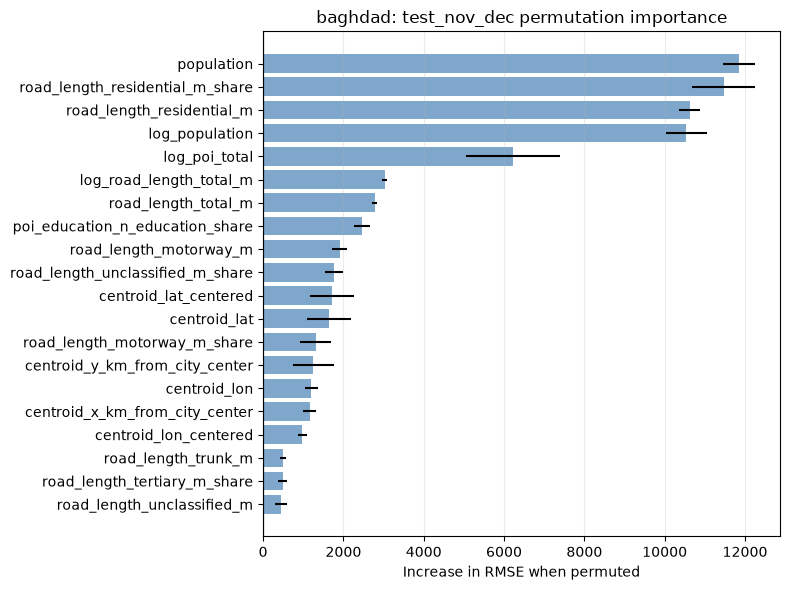

Saved permutation importance plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/baghdad_test_nov_dec_permutation_importance.png
Saved period-specific permutation importance: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/period_specific_permutation_importance.csv


In [12]:
PERMUTATION_IMPORTANCE_REPEATS = 5
PERMUTATION_IMPORTANCE_MAX_ROWS = 3000
PERMUTATION_IMPORTANCE_TOP_N = 20

importance_rows = []

for city in DIAGNOSTIC_CITIES:
    artifact_path = OUTPUT_ROOT / city / "jan_aug_retrained_model_artifact.joblib"
    if not artifact_path.exists():
        print("Skipping {}: missing retrained artifact at {}".format(city, artifact_path))
        continue

    artifact = joblib.load(artifact_path)
    model = artifact["model"]
    feature_cols = artifact["feature_cols"]
    panel = engineered_city_panels[city].dropna(subset=[TARGET_COL] + feature_cols).copy()
    panel = panel.loc[~panel[MONTH_COL].isin(EXCLUDED_MONTHS)].copy()

    print()
    print("Permutation importance for {} ({})".format(city, artifact["model_name"]))
    for period_name, months in PERIOD_DEFINITIONS.items():
        period_df = panel.loc[panel[MONTH_COL].isin(months)].copy()
        if period_df.empty:
            continue
        if len(period_df) > PERMUTATION_IMPORTANCE_MAX_ROWS:
            period_df = period_df.sample(PERMUTATION_IMPORTANCE_MAX_ROWS, random_state=RANDOM_STATE)

        result = permutation_importance(
            model,
            period_df[feature_cols],
            period_df[TARGET_COL],
            scoring="neg_root_mean_squared_error",
            n_repeats=PERMUTATION_IMPORTANCE_REPEATS,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        period_importance = pd.DataFrame({
            "city": city,
            "model_name": artifact["model_name"],
            "period": period_name,
            "months": month_label(months),
            "feature": feature_cols,
            "increase_rmse_mean": result.importances_mean,
            "increase_rmse_sd": result.importances_std,
            "sample_rows": len(period_df),
        }).sort_values("increase_rmse_mean", ascending=False)
        importance_rows.append(period_importance)
        display(period_importance.head(PERMUTATION_IMPORTANCE_TOP_N))

        fig, ax = plt.subplots(figsize=(8, 6))
        top = period_importance.head(PERMUTATION_IMPORTANCE_TOP_N).iloc[::-1]
        ax.barh(top["feature"], top["increase_rmse_mean"], xerr=top["increase_rmse_sd"], color="#7FA7CC")
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Increase in RMSE when permuted")
        ax.set_title(f"{city}: {period_name} permutation importance")
        ax.grid(axis="x", alpha=0.25)
        fig.tight_layout()
        fig_path = DIAGNOSTIC_OUTPUT_DIR / f"{city}_{period_name}_permutation_importance.png"
        fig.savefig(fig_path, dpi=220, bbox_inches="tight")
        plt.show()
        print("Saved permutation importance plot:", fig_path)

if importance_rows:
    period_importance_df = pd.concat(importance_rows, ignore_index=True)
else:
    period_importance_df = pd.DataFrame()

importance_path = DIAGNOSTIC_OUTPUT_DIR / "period_specific_permutation_importance.csv"
period_importance_df.to_csv(importance_path, index=False)
print("Saved period-specific permutation importance:", importance_path)




### 6.4 Group Ablation Diagnostics

This diagnostic keeps the selected model type and hyperparameters fixed, retrains on January-August, and removes one group of predictors at a time.

The goal is to check whether transfer performance changes when removing:

- NO₂;
- weather variables;
- geographic variables.

This is not a new model-selection step. It is a feature-dependence diagnostic.



Group ablation for mexico_city (random_forest)

Group ablation for lima (random_forest)

Group ablation for baghdad (random_forest)
Saved group ablation diagnostics: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/group_ablation_diagnostics.csv


,city,ablation,model_name,feature_count,dropped_columns,validation_sep_oct_rmse,test_nov_dec_rmse,validation_rmse_change_vs_full,test_rmse_change_vs_full,validation_pct_rmse_change_vs_full,test_pct_rmse_change_vs_full
11,baghdad,drop_geography,random_forest,41,"centroid_lon,centroid_lat,centroid_lon_centere...",96448.400740,112114.445927,861.812904,-2825.599680,0.901604,-2.458325
9,baghdad,drop_no2,random_forest,47,no2,93405.476245,116710.019106,-2181.111592,1769.973499,-2.281818,1.539910
10,baghdad,drop_weather,random_forest,46,"era5_temp,wind_speed",106638.453496,80474.187336,11051.865659,-34465.858272,11.562151,-29.985944
8,baghdad,full_selected_features,random_forest,48,,95586.587837,114940.045607,0.000000,0.000000,0.000000,0.000000
7,lima,drop_geography,random_forest,41,"centroid_lon,centroid_lat,centroid_lon_centere...",110348.360715,72170.729772,2306.769715,1896.924356,2.135076,2.699333
5,lima,drop_no2,random_forest,47,no2,109553.205520,70441.283447,1511.614521,167.478032,1.399104,0.238322
6,lima,drop_weather,random_forest,46,"era5_temp,wind_speed",117106.340364,71348.223791,9064.749365,1074.418375,8.390055,1.528903
4,lima,full_selected_features,random_forest,48,,108041.590999,70273.805415,0.000000,0.000000,0.000000,0.000000
3,mexico_city,drop_geography,random_forest,41,"centroid_lon,centroid_lat,centroid_lon_centere...",63826.384938,57033.361603,-1957.093859,70.670761,-2.975054,0.124065
1,mexico_city,drop_no2,random_forest,47,no2,72888.695158,40882.061043,7105.216361,-16080.629799,10.800913,-28.230109


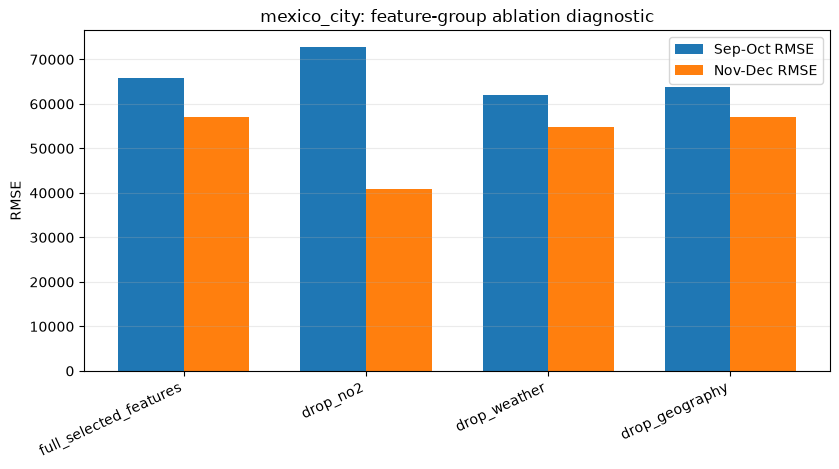

Saved group ablation plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/mexico_city_group_ablation_rmse.png


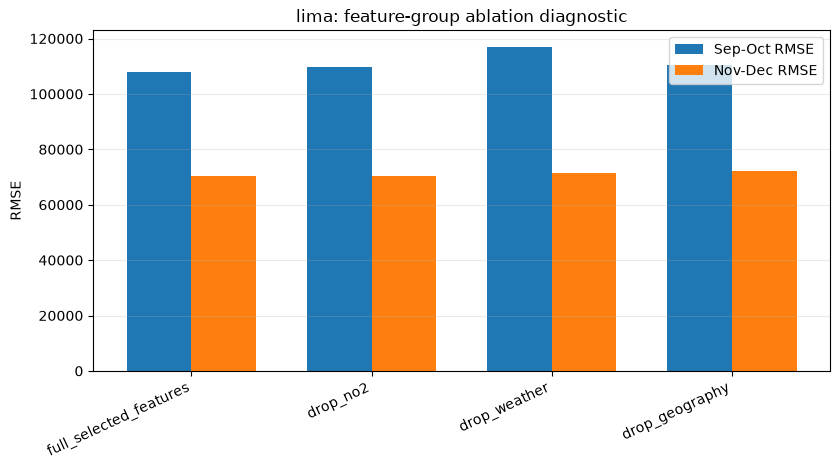

Saved group ablation plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/lima_group_ablation_rmse.png


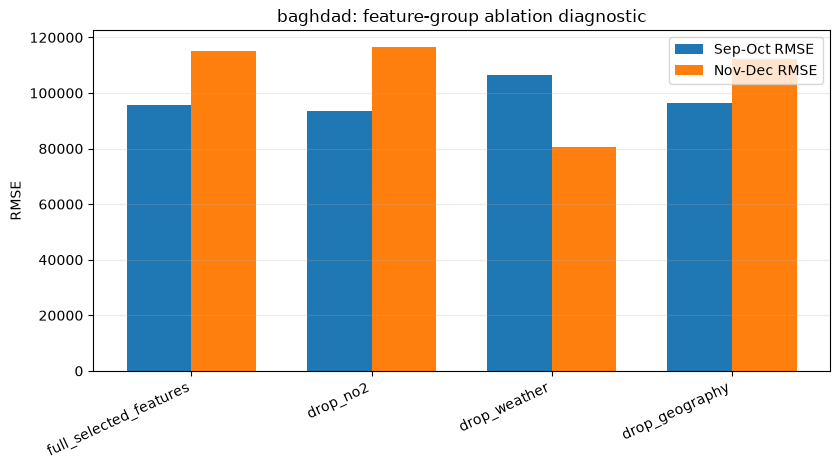

Saved group ablation plot: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_retrain_jan_aug_compare_val_test_v25/diagnostics/baghdad_group_ablation_rmse.png


In [13]:
GROUP_ABLATION_DEFINITIONS = {
    "full_selected_features": [],
    "drop_no2": ["no2"],
    "drop_weather": ["era5_temp", "wind_speed"],
    "drop_geography": [
        "centroid_lon", "centroid_lat",
        "centroid_lon_centered", "centroid_lat_centered",
        "centroid_x_km_from_city_center", "centroid_y_km_from_city_center",
        "distance_to_city_center_km",
    ],
}

ablation_rows = []

for city in DIAGNOSTIC_CITIES:
    selected = selected_artifacts[city]
    panel = engineered_city_panels[city].copy()
    original_features = selected["feature_cols"]

    print()
    print("Group ablation for {} ({})".format(city, selected["model_name"]))
    for ablation_name, dropped_cols in GROUP_ABLATION_DEFINITIONS.items():
        feature_cols = [col for col in original_features if col not in dropped_cols]
        if len(feature_cols) == len(original_features) and ablation_name != "full_selected_features":
            print("  {}: skipped because none of the requested columns are in the feature set".format(ablation_name))
            continue

        model_panel = panel.dropna(subset=[TARGET_COL] + feature_cols).copy()
        model_panel = model_panel.loc[~model_panel[MONTH_COL].isin(EXCLUDED_MONTHS)].copy()
        train_df = model_panel.loc[model_panel[MONTH_COL].isin(TRAIN_MONTHS)].copy()
        validation_df = model_panel.loc[model_panel[MONTH_COL].isin(VALIDATION_MONTHS)].copy()
        test_df = model_panel.loc[model_panel[MONTH_COL].isin(TEST_MONTHS)].copy()
        if train_df.empty or validation_df.empty or test_df.empty:
            continue

        model = build_model(selected["model_name"], selected["params"])
        model.fit(train_df[feature_cols], train_df[TARGET_COL])

        split_dfs = {
            "train_jan_aug": train_df,
            "validation_sep_oct": validation_df,
            "test_nov_dec": test_df,
        }
        row = {
            "city": city,
            "ablation": ablation_name,
            "model_name": selected["model_name"],
            "dropped_columns": ",".join([col for col in dropped_cols if col in original_features]),
            "feature_count": len(feature_cols),
        }
        for split_name, split_df in split_dfs.items():
            pred = model.predict(split_df[feature_cols])
            metrics = evaluate_regression(split_df[TARGET_COL], pred)
            for metric_name, metric_value in metrics.items():
                row[f"{split_name}_{metric_name}"] = metric_value
        ablation_rows.append(row)

ablation_df = pd.DataFrame(ablation_rows)
if not ablation_df.empty:
    full_lookup = ablation_df.loc[ablation_df["ablation"] == "full_selected_features", [
        "city", "validation_sep_oct_rmse", "test_nov_dec_rmse"
    ]].rename(columns={
        "validation_sep_oct_rmse": "full_validation_rmse",
        "test_nov_dec_rmse": "full_test_rmse",
    })
    ablation_df = ablation_df.merge(full_lookup, on="city", how="left")
    ablation_df["validation_rmse_change_vs_full"] = ablation_df["validation_sep_oct_rmse"] - ablation_df["full_validation_rmse"]
    ablation_df["test_rmse_change_vs_full"] = ablation_df["test_nov_dec_rmse"] - ablation_df["full_test_rmse"]
    ablation_df["validation_pct_rmse_change_vs_full"] = 100 * ablation_df["validation_rmse_change_vs_full"] / ablation_df["full_validation_rmse"]
    ablation_df["test_pct_rmse_change_vs_full"] = 100 * ablation_df["test_rmse_change_vs_full"] / ablation_df["full_test_rmse"]

ablation_path = DIAGNOSTIC_OUTPUT_DIR / "group_ablation_diagnostics.csv"
ablation_df.to_csv(ablation_path, index=False)
print("Saved group ablation diagnostics:", ablation_path)

display_cols = [
    "city", "ablation", "model_name", "feature_count", "dropped_columns",
    "validation_sep_oct_rmse", "test_nov_dec_rmse",
    "validation_rmse_change_vs_full", "test_rmse_change_vs_full",
    "validation_pct_rmse_change_vs_full", "test_pct_rmse_change_vs_full",
]
display(ablation_df[[col for col in display_cols if col in ablation_df.columns]].sort_values(["city", "ablation"]))

if not ablation_df.empty:
    for city in DIAGNOSTIC_CITIES:
        city_ablation = ablation_df.loc[ablation_df["city"] == city].copy()
        if city_ablation.empty:
            continue
        fig, ax = plt.subplots(figsize=(8.5, 4.8))
        x = np.arange(len(city_ablation))
        width = 0.36
        ax.bar(x - width/2, city_ablation["validation_sep_oct_rmse"], width, label="Sep-Oct RMSE")
        ax.bar(x + width/2, city_ablation["test_nov_dec_rmse"], width, label="Nov-Dec RMSE")
        ax.set_xticks(x)
        ax.set_xticklabels(city_ablation["ablation"], rotation=25, ha="right")
        ax.set_ylabel("RMSE")
        ax.set_title(f"{city}: feature-group ablation diagnostic")
        ax.grid(axis="y", alpha=0.25)
        ax.legend()
        fig.tight_layout()
        fig_path = DIAGNOSTIC_OUTPUT_DIR / f"{city}_group_ablation_rmse.png"
        fig.savefig(fig_path, dpi=220, bbox_inches="tight")
        plt.show()
        print("Saved group ablation plot:", fig_path)




## 7. Diagnostic Reading Guide

Use these outputs in order:

1. Check whether the target or dynamic predictors shift between January-August, September-October, and November-December.
2. Check whether errors are concentrated in one month.
3. Use period-specific permutation importance to see whether the model relies on different variables in different periods.
4. Use group ablation to see whether NO₂, weather, or geography explains transfer differences.

A useful interpretation pattern is:

- if target and predictor distributions shift strongly, later-month errors may reflect temporal distribution shift;
- if only one test month is difficult, report the month-specific issue rather than treating the whole model as unstable;
- if removing one feature group improves later-period performance, that group may not transfer well from early-year training to later months.


## 8. Summary Interpretation Guide

This notebook answers three practical questions:

1. **Is November-December harder than September-October under the same January-August training window?**  
   Check `test_minus_validation_rmse` and `test_vs_validation_rmse_ratio`.

2. **How much does the main model's final refit on training plus validation months help?**  
   Compare the January-August-only test RMSE with the main model's final test RMSE after refitting on the full development period.

3. **Is weak test performance mainly a final-test problem or a broader temporal-transfer problem?**  
   Check period distributions, monthly errors, permutation importance, and group ablation results together.

This notebook is a diagnostic companion to the main tuned model. It should support interpretation, not replace the original model-selection rule.
